In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from adjustText import adjust_text
import numpy as np
import json
import polars as pl
import geopandas as gpd
from shapely.geometry import Point
from matplotlib import gridspec
import matplotlib.colors as colors
from itertools import combinations
from scipy.spatial.distance import jensenshannon
from scipy.spatial.distance import cosine
import scipy
import seaborn as sns
from pathlib import Path
#from plots import *

In [10]:
# set directory
cwd = Path.cwd()
parent_dir = cwd.parent.parent
parent_dir

PosixPath('/data/verorsanigo/EU-project/stuff first paper to revise code')

# INFO

CORDIS organization activity types
- HES: Higher or Secondary Education Establishments
- REC: Research Organisations
- PRC: Private for-profit entities (excluding Higher or Secondary Education Establishments)
- PUB: Public bodies (excluding Research Organisations and Secondary or Higher Education Establishments)

# Read data

In [ ]:
# data dir
data_dir = parent_dir / 'Data'

In [ ]:
# df projects without empty objective text
df = pd.read_csv(data_dir / 'project_until_2025_no_nan_obj.csv')

In [ ]:
# paths

# topics
umap_bert = 2
hdbscan_bert = 100 # 59 before for unitl h2020
df_topics_path = '../embeddings_topics/description topics/umap_' + str(umap_bert) + '_hdbscan_' + str(hdbscan_bert) + '/topics_project_umap_' + str(umap_bert) + '_hdbscan_' + str(hdbscan_bert) + '.csv'
df_info_topics_path = '../embeddings_topics/description topics/umap_' + str(umap_bert) + '_hdbscan_' + str(hdbscan_bert) + '/info_topic_umap_' + str(umap_bert) + 'hdbscan_' + str(hdbscan_bert) + '.csv'

# embeddings
embeddings_path = '../embeddings_topics/description embeddings/bge_1024dim.npy'
red_embeddings_path = '../embeddings_topics/description embeddings/reduced_bge_1024dim.npy'

# efta countries
efta_df = pd.read_csv(data_dir / 'efta countries.csv')
efta_countries = list(efta_df['country'].str.lower())

## Read topics df

### Normal topics

In [ ]:
# read topics df
df_topics = pd.read_csv(df_topics_path)

# read topics info df
df_topics_info = pd.read_csv(df_info_topics_path)

# read df projects
df_h2020 = pd.read_csv(data_dir / 'projects' / 'project_8.csv')
df_heu = pd.read_csv(data_dir / 'projects' / 'project_9.csv')

df_h2020['fp'] = 8
df_heu['fp'] = 9

In [ ]:
# organizations df
df8 = pd.read_csv(data_dir / 'organizations' / 'org_8_updated_lat_lon.csv')
df9 = pd.read_csv(data_dir / 'organizations' / 'org_9_updated_lat_lon.csv')

/tmp/ipykernel_521596/291698341.py:2: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df8 = pd.read_csv(data_dir / 'organizations/org_8_updated_lat_lon.csv')
/tmp/ipykernel_521596/291698341.py:3: DtypeWarning: Columns (20,21,23,24,26,27,41,45) have mixed types. Specify dtype option on import or set low_memory=False.
  df9 = pd.read_csv(data_dir / 'organizations/org_9_updated_lat_lon.csv')


### Reduce topics following hierarchy

#### 1) With file from automatic procedure based on distance

In [ ]:
# NB: no need to run it if we already have the final file with merged topics with the chosen threshold

# threshold merging
threshold = 1.0

# merged topics dir
merged_topics_dir_path = '../embeddings_topics/description topics/umap_2_hdbscan_100/merged topics/'

# input file
merged_file = merged_topics_dir_path + 'merged_topics_' + str(threshold) + '.csv'
merged_df = pl.read_csv(merged_file)

# explode column of groups
merged_df = merged_df.with_columns(
    pl.col('merged_topics').map_elements(lambda x: json.loads(x) if x else[]).alias('merged_topics')
    )
exploded_df = (merged_df.with_columns(pl.col('merged_topics').alias('merged_topic_copy'))
               .explode(pl.col('merged_topics'))
               .rename({'merged_topics': 'topic_num_forced', 'Parent_Name': 'macro_topic_name', 'Parent_ID': 'macro_topic'})
)

# remove useless columns
exploded_df_filter = exploded_df.select(['macro_topic', 'macro_topic_name', 'Distance', 'topic_num_forced'])

# save df merged topics
#exploded_df_filter.write_csv(merged_topics_dir_path + 'merged_topics_final_' + str(threshold) + '.csv')

#### 2) With file obtained manually looking at the hierarchy image

In [ ]:
# NB: no need to run it if we already have the final file with merged topics with the chosen threshold

# threshold merging
threshold = 1.0

# merged topics dir
merged_topics_dir_path = '../embeddings_topics/description topics/umap_2_hdbscan_100/merged topics/'

# input file
merged_file = merged_topics_dir_path + 'merged_topics_manual_' + str(threshold) + '.csv'
merged_df = pl.read_csv(merged_file)

# explode column of groups
merged_df = merged_df.with_columns(
    pl.col('merged_topics').map_elements(lambda x: json.loads(x) if x else[]).alias('merged_topics')
    )
exploded_df = (merged_df.with_columns(pl.col('merged_topics').alias('merged_topic_copy'))
               .explode(pl.col('merged_topics'))
               .rename({'merged_topics': 'topic_num_forced'})
)

# remove useless columns
exploded_df_filter = exploded_df.select(['macro_topic', 'macro_topic_name', 'topic_num_forced'])

# save df merged topics
#exploded_df_filter.write_csv(merged_topics_dir_path + 'merged_topics_final_manual_' + str(threshold) + '.csv')

### Macro topics

In [ ]:
# open file with choesen threshold

# threshold merging
threshold = 1.0 #0.7 

merged_topics_dir_path = '../embeddings_topics/description topics/umap_2_hdbscan_100/merged topics/'

# read macro topics df
#df_new_topics = pd.read_csv(merged_topics_dir_path + '/merged_topics_final_' + str(threshold) + '.csv')

# read macro topics df MANUAL -> USE FOR THE PAPER (BGE FOLDER)
df_new_topics = pd.read_csv(merged_topics_dir_path + '/merged_topics_final_manual_' + str(threshold) + '.csv')

In [9]:
df_new_topics['macro_topic_name'].unique()

array(['Quantum & Materials Physics', 'Energy', 'Pollution',
       'Biology & Cells', 'Research and Innovation Promotion',
       'Transports & Automation', 'Virus & Bacteria', 'Society', 'Maths',
       'Food & Plants', 'Chemistry', 'Medicine', 'Climate & Environment',
       'Manufacturing & Construction', 'Computer Science & IT', 'Space'],
      dtype=object)

## Read embeddings df

In [10]:
red_embeddings = np.load(red_embeddings_path)

In [11]:
df_topics['red_embeddings'] = list(red_embeddings)

In [12]:
# merge with normal topics
df_tot_8_1 = pd.merge(df_h2020, df_topics, on=['id', 'fp'], how='left')
#df_heu = df_heu.rename(columns={'rcn': 'rcn_old', 'id': 'rcn'})
df_tot_9_1 = pd.merge(df_heu, df_topics, on=['id', 'fp'], how='left')

# merge with macro topics
df_tot_8 = pd.merge(df_tot_8_1, df_new_topics, on='topic_num_forced', how='left')
df_tot_9 = pd.merge(df_tot_9_1, df_new_topics, on='topic_num_forced', how='left')

### Group by topic and compute topic centres

In [13]:
# compute topics centres

df_tot = pd.concat([df_tot_8, df_tot_9])

grouped_centres = df_tot.groupby('topic_num_forced').agg(mean_red_emb=pd.NamedAgg(column='red_embeddings', aggfunc='mean')).reset_index()
grouped_centres_macro = df_tot.groupby('macro_topic').agg(mean_red_emb_macro=pd.NamedAgg(column='red_embeddings', aggfunc='mean')).reset_index()

In [14]:
# put labels and topic centres

df_tot_8_centres = pd.merge(df_tot_8, grouped_centres, on='topic_num_forced', how='left')
df_tot_9_centres = pd.merge(df_tot_9, grouped_centres, on='topic_num_forced', how='left')
df_tot_8_centres = pd.merge(df_tot_8_centres, grouped_centres_macro, on='macro_topic', how='left')
df_tot_9_centres = pd.merge(df_tot_9_centres, grouped_centres_macro, on='macro_topic', how='left')

# rename topics column
df_topics_info = df_topics_info.rename(columns={'Topic': 'topic_num_forced'})
df_tot_8_label = pd.merge(df_tot_8_centres, df_topics_info, on='topic_num_forced', how='left')
df_tot_9_label = pd.merge(df_tot_9_centres, df_topics_info, on='topic_num_forced', how='left')

## Read organizations

In [15]:
# read organization files

org_8 = pd.read_csv(data_dir / 'organizations/org_8_updated_lat_lon.csv')
org_9 = pd.read_csv(data_dir / 'organizations/org_9_updated_lat_lon.csv')

/tmp/ipykernel_521596/3767563496.py:3: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  org_8 = pd.read_csv(data_dir / 'organizations/org_8_updated_lat_lon.csv')
/tmp/ipykernel_521596/3767563496.py:4: DtypeWarning: Columns (20,21,23,24,26,27,41,45) have mixed types. Specify dtype option on import or set low_memory=False.
  org_9 = pd.read_csv(data_dir / 'organizations/org_9_updated_lat_lon.csv')


In [16]:
# merge projects and organizations

# rename project id column
df_tot_8_label = df_tot_8_label.rename(columns={'id': 'projectID'})
df_tot_9_label = df_tot_9_label.rename(columns={'id': 'projectID'})

org_proj_8 = pd.merge(org_8, df_tot_8_label, on='projectID', how='left')
org_proj_9 = pd.merge(org_9, df_tot_9_label, on='projectID', how='left')

org_proj_tot = pd.concat([org_proj_8, org_proj_9]).reset_index(drop=True)

In [17]:
# add new topics to df topics

org_proj_tot['activityType_new'] = org_proj_tot['activityType'].replace({'HES': 'RES', 'REC': 'RES', 'PRC': 'IND', 'PUB': 'OTH', 'OTH': 'OTH'})

org_proj_tot_res = org_proj_tot[org_proj_tot['activityType_new'] == 'RES']
org_proj_tot_ind = org_proj_tot[org_proj_tot['activityType_new'] == 'IND']

org_proj_tot_8 = org_proj_tot[org_proj_tot['fp'] == 8]
org_proj_tot_9 = org_proj_tot[org_proj_tot['fp'] == 9]

In [18]:
# calculate netECContribution for Italy
org_proj_tot_tot = pd.concat([org_proj_tot_8, org_proj_9])

org_proj_tot_it = org_proj_tot_tot[org_proj_tot_tot['country_code_ok'] == 'it']
org_proj_tot_it['netEcContribution'] = org_proj_tot_it['netEcContribution'].astype(float) #str.replace(',', '.').

sum_ecNetContr_it = org_proj_tot_it['netEcContribution'].sum()

# read population df
pop_df = pd.read_csv(data_dir / 'population per year.csv')
pop_2023 = pop_df[['2023', 'Alpha-2 code']]
pop_it = pop_2023[pop_2023['Alpha-2 code'] == 'IT']['2023'].values[0]
sum_ecNetContr_it_capita = sum_ecNetContr_it / pop_it

/tmp/ipykernel_521596/2791142263.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  org_proj_tot_it['netEcContribution'] = org_proj_tot_it['netEcContribution'].astype(float) #str.replace(',', '.').


# Topics

## Plot tot topics

/tmp/ipykernel_521596/4286306992.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colormap = plt.cm.get_cmap('tab20', len(org_proj_tot['topic_num_forced'].unique()))


(4.158630681037903, 14.787902998924256, -4.878152167797088, 14.896505868434906)

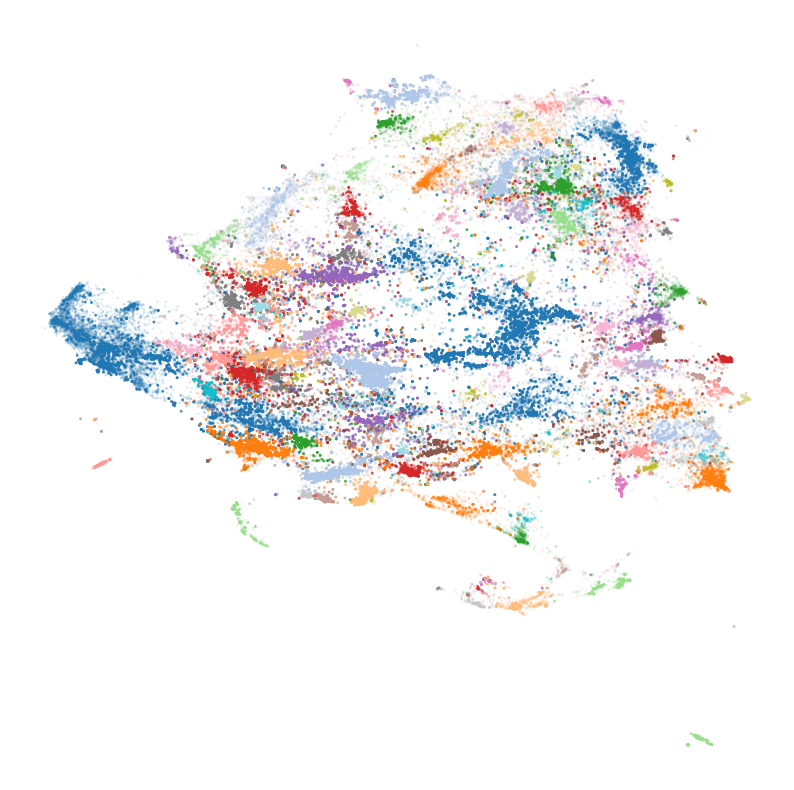

In [19]:
array_embeddings = np.array(list(org_proj_tot['red_embeddings']))

labels_df = org_proj_tot[['Name', 'topic_num_forced', 'mean_red_emb']].drop_duplicates(subset=['Name']).reset_index(drop=True)
mean_red_emb = np.array(list(labels_df['mean_red_emb']))

fig, ax = plt.subplots(figsize=(10, 10))
topics_tot = list(org_proj_tot['topic_num_forced'])
colormap = plt.cm.get_cmap('tab20', len(org_proj_tot['topic_num_forced'].unique()))
ax.scatter(array_embeddings[:, 0], array_embeddings[:, 1], c=topics_tot, cmap=colormap,  s=1, alpha=0.1)
ax.axis('off')

#fig.savefig('FBK analysis/plot_tot_topics.png'

## FBK focus

### Plot comparison FBK - organizations

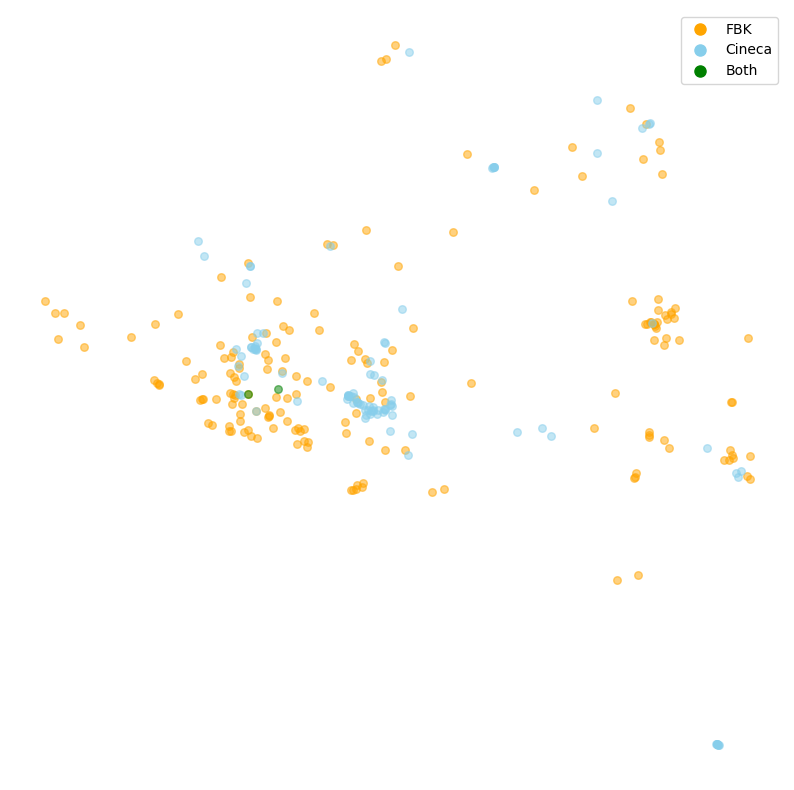

In [20]:
org_1 = 'fondazione bruno kessler'
org_2 = 'cineca consorzio interuniversitario'
#'universita degli studi di trento''politecnico di milano'
#'alma mater studiorum - universita di bologna'

# legend labels'
label_1 = 'FBK'
label_2 = 'Cineca'
label_3 = 'Both'

# org_df
org_df_1_tot = org_proj_tot[org_proj_tot['name'] == org_1]
org_df_2_tot = org_proj_tot[org_proj_tot['name'] == org_2]
set_1 = set(list(org_df_1_tot['projectID']))
set_2 = set(list(org_df_2_tot['projectID']))
proj_1 = list(set_1-set_2)
proj_2 = list(set_2-set_1)
proj_both = list(set_1.intersection(set_2))

org_df_1 = org_df_1_tot[org_df_1_tot['projectID'].isin(proj_1)]
org_df_2 = org_df_2_tot[org_df_2_tot['projectID'].isin(proj_2)]
org_df_both = org_proj_tot[org_proj_tot['projectID'].isin(proj_both)].drop_duplicates(subset='projectID')

colors = ['orange', 'skyblue', 'green']


fig, ax = plt.subplots(figsize=(10, 10))

i = 0

array_embeddings = np.array(list(org_df_1['red_embeddings']))
ax.scatter(array_embeddings[:, 0], array_embeddings[:, 1], c=colors[0], s=30, alpha=0.5)#cmap=colormap,  

array_embeddings = np.array(list(org_df_2['red_embeddings']))
ax.scatter(array_embeddings[:, 0], array_embeddings[:, 1], c=colors[1], s=30, alpha=0.5)#cmap=colormap,

array_embeddings = np.array(list(org_df_both['red_embeddings']))
ax.scatter(array_embeddings[:, 0], array_embeddings[:, 1], c=colors[2], s=30, alpha=0.5)#cmap=colormap,  
    
# set legend characteristics
legend_handles = [
    mlines.Line2D([], [], color="orange", marker="o", linestyle="None", markersize=8, label=label_1),
    mlines.Line2D([], [], color="skyblue", marker="o", linestyle="None", markersize=8, label=label_2),
    mlines.Line2D([], [], color="green", marker="o", linestyle="None", markersize=8, label=label_3)
]

ax.axis('off')
ax.legend(handles=legend_handles)

#fig.savefig('FBK analysis/' + label_1 + ' - ' + label_2 + '.png')

### Plot proj FBK

In [22]:
org = 'fondazione bruno kessler'
org_proj_8_fbk = org_proj_8[org_proj_8['name'] == org]
org_proj_9_fbk = org_proj_9[org_proj_9['name'] == org]
org_proj_tot_fbk = org_proj_tot[org_proj_tot['name'] == org]

/tmp/ipykernel_521596/2896045207.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colormap = plt.cm.get_cmap('tab20', len(org_proj_tot_fbk['topic_num_forced'].unique()))


(4.482621169090271,
 14.471209073066712,
 -0.49686218425631523,
 13.57012602314353)

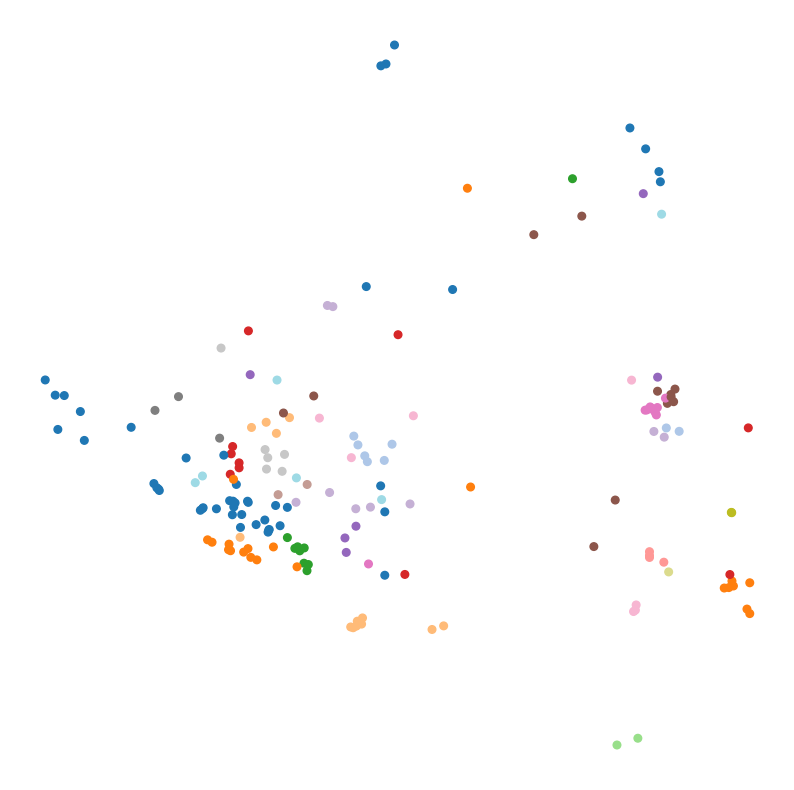

In [23]:
array_embeddings = np.array(list(org_proj_tot_fbk['red_embeddings']))

labels_df = org_proj_tot_fbk[['Name', 'topic_num_forced', 'mean_red_emb']].drop_duplicates(subset=['Name']).reset_index(drop=True) #pd.merge(df_topics_info, org_proj_fbk, on='topic_num_forced', how='left') 
mean_red_emb = np.array(list(labels_df['mean_red_emb']))

fig, ax = plt.subplots(figsize=(10, 10))
topics_tot = list(org_proj_tot_fbk['topic_num_forced'])
colormap = plt.cm.get_cmap('tab20', len(org_proj_tot_fbk['topic_num_forced'].unique()))

ax.scatter(array_embeddings[:, 0], array_embeddings[:, 1], c=topics_tot, cmap=colormap,  s=30)

ax.axis('off')

#fig.savefig('FBK analysis/FBK topics tot.png')

## Plot macro topics

### Plot macro topics tot

In [24]:
grouped_centres_macro = df_tot.groupby('macro_topic').agg(mean_red_emb_macro=pd.NamedAgg(column='red_embeddings', aggfunc='mean')).reset_index()

# put labels and topic centres

df_tot_8_centres = pd.merge(org_proj_tot, grouped_centres_macro, on='macro_topic', how='left')
df_tot_9_centres = pd.merge(org_proj_tot, grouped_centres_macro, on='macro_topic', how='left')

# rename topics column
'''df_topics_info = df_topics_info.rename(columns={'Topic': 'topic_num_forced'})
df_tot_8_label = pd.merge(df_tot_8_centres, df_topics_info, on='topic_num_forced', how='left')
df_tot_9_label = pd.merge(df_tot_9_centres, df_topics_info, on='topic_num_forced', how='left')'''

df_tot_label = pd.concat([df_tot_8_centres, df_tot_9_centres])

In [ ]:
array_embeddings = np.array(list(org_proj_tot['red_embeddings']))

labels_df = org_proj_tot[['macro_topic_name', 'macro_topic', 'mean_red_emb_macro']].drop_duplicates(subset=['macro_topic_name']).reset_index(drop=True) #pd.merge(df_topics_info, org_proj_fbk, on='topic_num_forced', how='left') 
mean_red_emb = np.array(list(labels_df['mean_red_emb_macro']))

fig, ax = plt.subplots(figsize=(10, 10))
topics_tot = list(org_proj_tot['macro_topic'])
colormap = plt.cm.get_cmap('tab20', len(org_proj_tot['macro_topic'].unique()))

ax.scatter(array_embeddings[:, 0], array_embeddings[:, 1], c=topics_tot, cmap=colormap,  s=1, alpha=0.1)

ax.axis('off')

# text
xt = list(mean_red_emb[:, 0])
yt = list(mean_red_emb[:, 1])
t = list(labels_df['macro_topic_name'])
# adjusttext
texts = [ax.text(xt[i], yt[i], t[i], ha='center', va='center', size=10, color='black') for i in range(len(xt))]

adjust_text(texts, ax=ax)


#fig.savefig('FBK analysis/tot macro topics.png')

## Group by topic, count number of projects, and sum ecMaxContribution

In [ ]:
# df
df_8 = org_proj_tot_8 # org_proj_8 or df_topics_new_embeddings_8
df_9 = org_proj_tot_9 # org_proj_9 or df_topics_new_embeddings_9
df_tot = org_proj_tot # org_proj_tot or df_topics_new_embeddings

# topic name column
topic_name_col = 'macro_topic_name' #macro_topic_name or Name
# topic number col
topic_num_col = 'macro_topic' #macro_topic or topic_num_forced

# remove rows where ecMaxContribution is HORIZON.1.2 or HORIZON.3.2
df_tot = df_tot[~df_tot['netEcContribution'].isin(['participant'])]
df_tot['netEcContribution'] = df_tot['netEcContribution'].astype(float)#.str.replace(',', '.')
df_grouped_money_proj_tot = df_tot.groupby([topic_num_col]).agg(sum_ecNetContribution=pd.NamedAgg(column='netEcContribution', aggfunc='sum'), count_proj=pd.NamedAgg(column='projectID', aggfunc='count'), topic_name=pd.NamedAgg(column=topic_name_col, aggfunc='first'), mean_red_emb=pd.NamedAgg(column='mean_red_emb', aggfunc='first'), country_code_original_nominatim=pd.NamedAgg(column='country_code_original_nominatim', aggfunc='first')).reset_index()
# filter efta countries
df_grouped_money_tot = df_grouped_money_proj_tot[df_grouped_money_proj_tot['country_code_original_nominatim'].isin(efta_countries)]
df_grouped_money_proj_tot

## Group by topic, organization and sum ecMaxContribution

In [26]:
# df
df_8 = org_proj_tot_8 # org_proj_8 or df_topics_new_embeddings_8
df_9 = org_proj_tot_9 # org_proj_9 or df_topics_new_embeddings_9
df_tot = org_proj_tot # org_proj_tot or df_topics_new_embeddings
# topic name column
topic_name_col = 'macro_topic_name' #macro_topic_name or Name
# topic number col
topic_num_col = 'macro_topic' #macro_topic or topic_num_forced
df_8['netEcContribution'] = df_8['netEcContribution'].astype(float) #str.replace(',', '.').
df_grouped_money_8 = df_8.groupby([topic_num_col, 'name']).agg(sum_ecNetContribution=pd.NamedAgg(column='netEcContribution', aggfunc='sum'), count_proj=pd.NamedAgg(column='projectID', aggfunc='count'), topic_name=pd.NamedAgg(column=topic_name_col, aggfunc='first'), mean_red_emb=pd.NamedAgg(column='mean_red_emb', aggfunc='first'), country_code_original_nominatim=pd.NamedAgg(column='country_code_original_nominatim', aggfunc='first')).reset_index()
# filter efta countries
df_grouped_money_8 = df_grouped_money_8[df_grouped_money_8['country_code_original_nominatim'].isin(efta_countries)]

# remove rows where ecMaxContribution is HORIZON.1.2 or HORIZON.3.2
df_9 = df_9[~df_9['netEcContribution'].isin(['participant'])]
df_9['netEcContribution'] = df_9['netEcContribution'].astype(float)#.str.replace(',', '.')
df_grouped_money_9 = df_9.groupby([topic_num_col, 'name']).agg(sum_ecNetContribution=pd.NamedAgg(column='netEcContribution', aggfunc='sum'), count_proj=pd.NamedAgg(column='projectID', aggfunc='count'), topic_name=pd.NamedAgg(column=topic_name_col, aggfunc='first'), mean_red_emb=pd.NamedAgg(column='mean_red_emb', aggfunc='first'), country_code_original_nominatim=pd.NamedAgg(column='country_code_original_nominatim', aggfunc='first')).reset_index()
# filter efta countries
df_grouped_money_9 = df_grouped_money_9[df_grouped_money_9['country_code_original_nominatim'].isin(efta_countries)]

#org_proj_tot_org = org_proj_tot_org[~org_proj_tot_org['ecContribution'].isin(['HORIZON.1.2', 'HORIZON.3.2'])]
df_tot = df_tot[~df_tot['netEcContribution'].isin(['participant'])]
df_tot['netEcContribution'] = df_tot['netEcContribution'].astype(float)#.str.replace(',', '.')
df_grouped_money_tot_org = df_tot.groupby([topic_num_col, 'name']).agg(sum_ecNetContribution=pd.NamedAgg(column='netEcContribution', aggfunc='sum'), count_proj=pd.NamedAgg(column='projectID', aggfunc='count'), topic_name=pd.NamedAgg(column=topic_name_col, aggfunc='first'), mean_red_emb=pd.NamedAgg(column='mean_red_emb', aggfunc='first')).reset_index()

/tmp/ipykernel_521596/2247411806.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_8['netEcContribution'] = df_8['netEcContribution'].astype(float) #str.replace(',', '.').
/tmp/ipykernel_521596/2247411806.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_9['netEcContribution'] = df_9['netEcContribution'].astype(float)#.str.replace(',', '.')
/tmp/ipykernel_521596/2247411806.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer

In [27]:
org_name_1 = 'fondazione bruno kessler'
org_df_select_1 = df_grouped_money_tot_org[df_grouped_money_tot_org['name'] == org_name_1]
org_df_sorted_1 = org_df_select_1.sort_values(by=['sum_ecNetContribution'], ascending=False)
org_10_1 = org_df_sorted_1.head(10)

org_name_2 = 'alma mater studiorum - universita di bologna' # 'politecnico di milano' #'cineca consorzio interuniversitario' # 'universita degli studi di trento'#
org_df_select_2 = df_grouped_money_tot_org[df_grouped_money_tot_org['name'] == org_name_2]
org_df_sorted_2 = org_df_select_2.sort_values(by=['sum_ecNetContribution'], ascending=False)

In [28]:
org_name_1 = 'fondazione bruno kessler'
fbk_money_8 = df_grouped_money_8[df_grouped_money_8['name'] == org_name_1].sort_values(by='sum_ecNetContribution', ascending=False)
fbk_money_9 = df_grouped_money_9[df_grouped_money_9['name'] == org_name_1].sort_values(by='sum_ecNetContribution', ascending=False)
fbk_money_tot = df_grouped_money_tot_org[df_grouped_money_tot_org['name'] == org_name_1].sort_values(by='sum_ecNetContribution', ascending=False)

### Plot top-10 topics FBK

['Manufacturing & Construction', 'Biology & Cells', 'Virus & Bacteria', 'Climate & Environment', 'Food & Plants', 'Maths', 'Research and Innovation Promotion', 'Medicine', 'Transports & Automation', 'Energy', 'Society', 'Quantum & Materials Physics', 'Computer Science & IT']


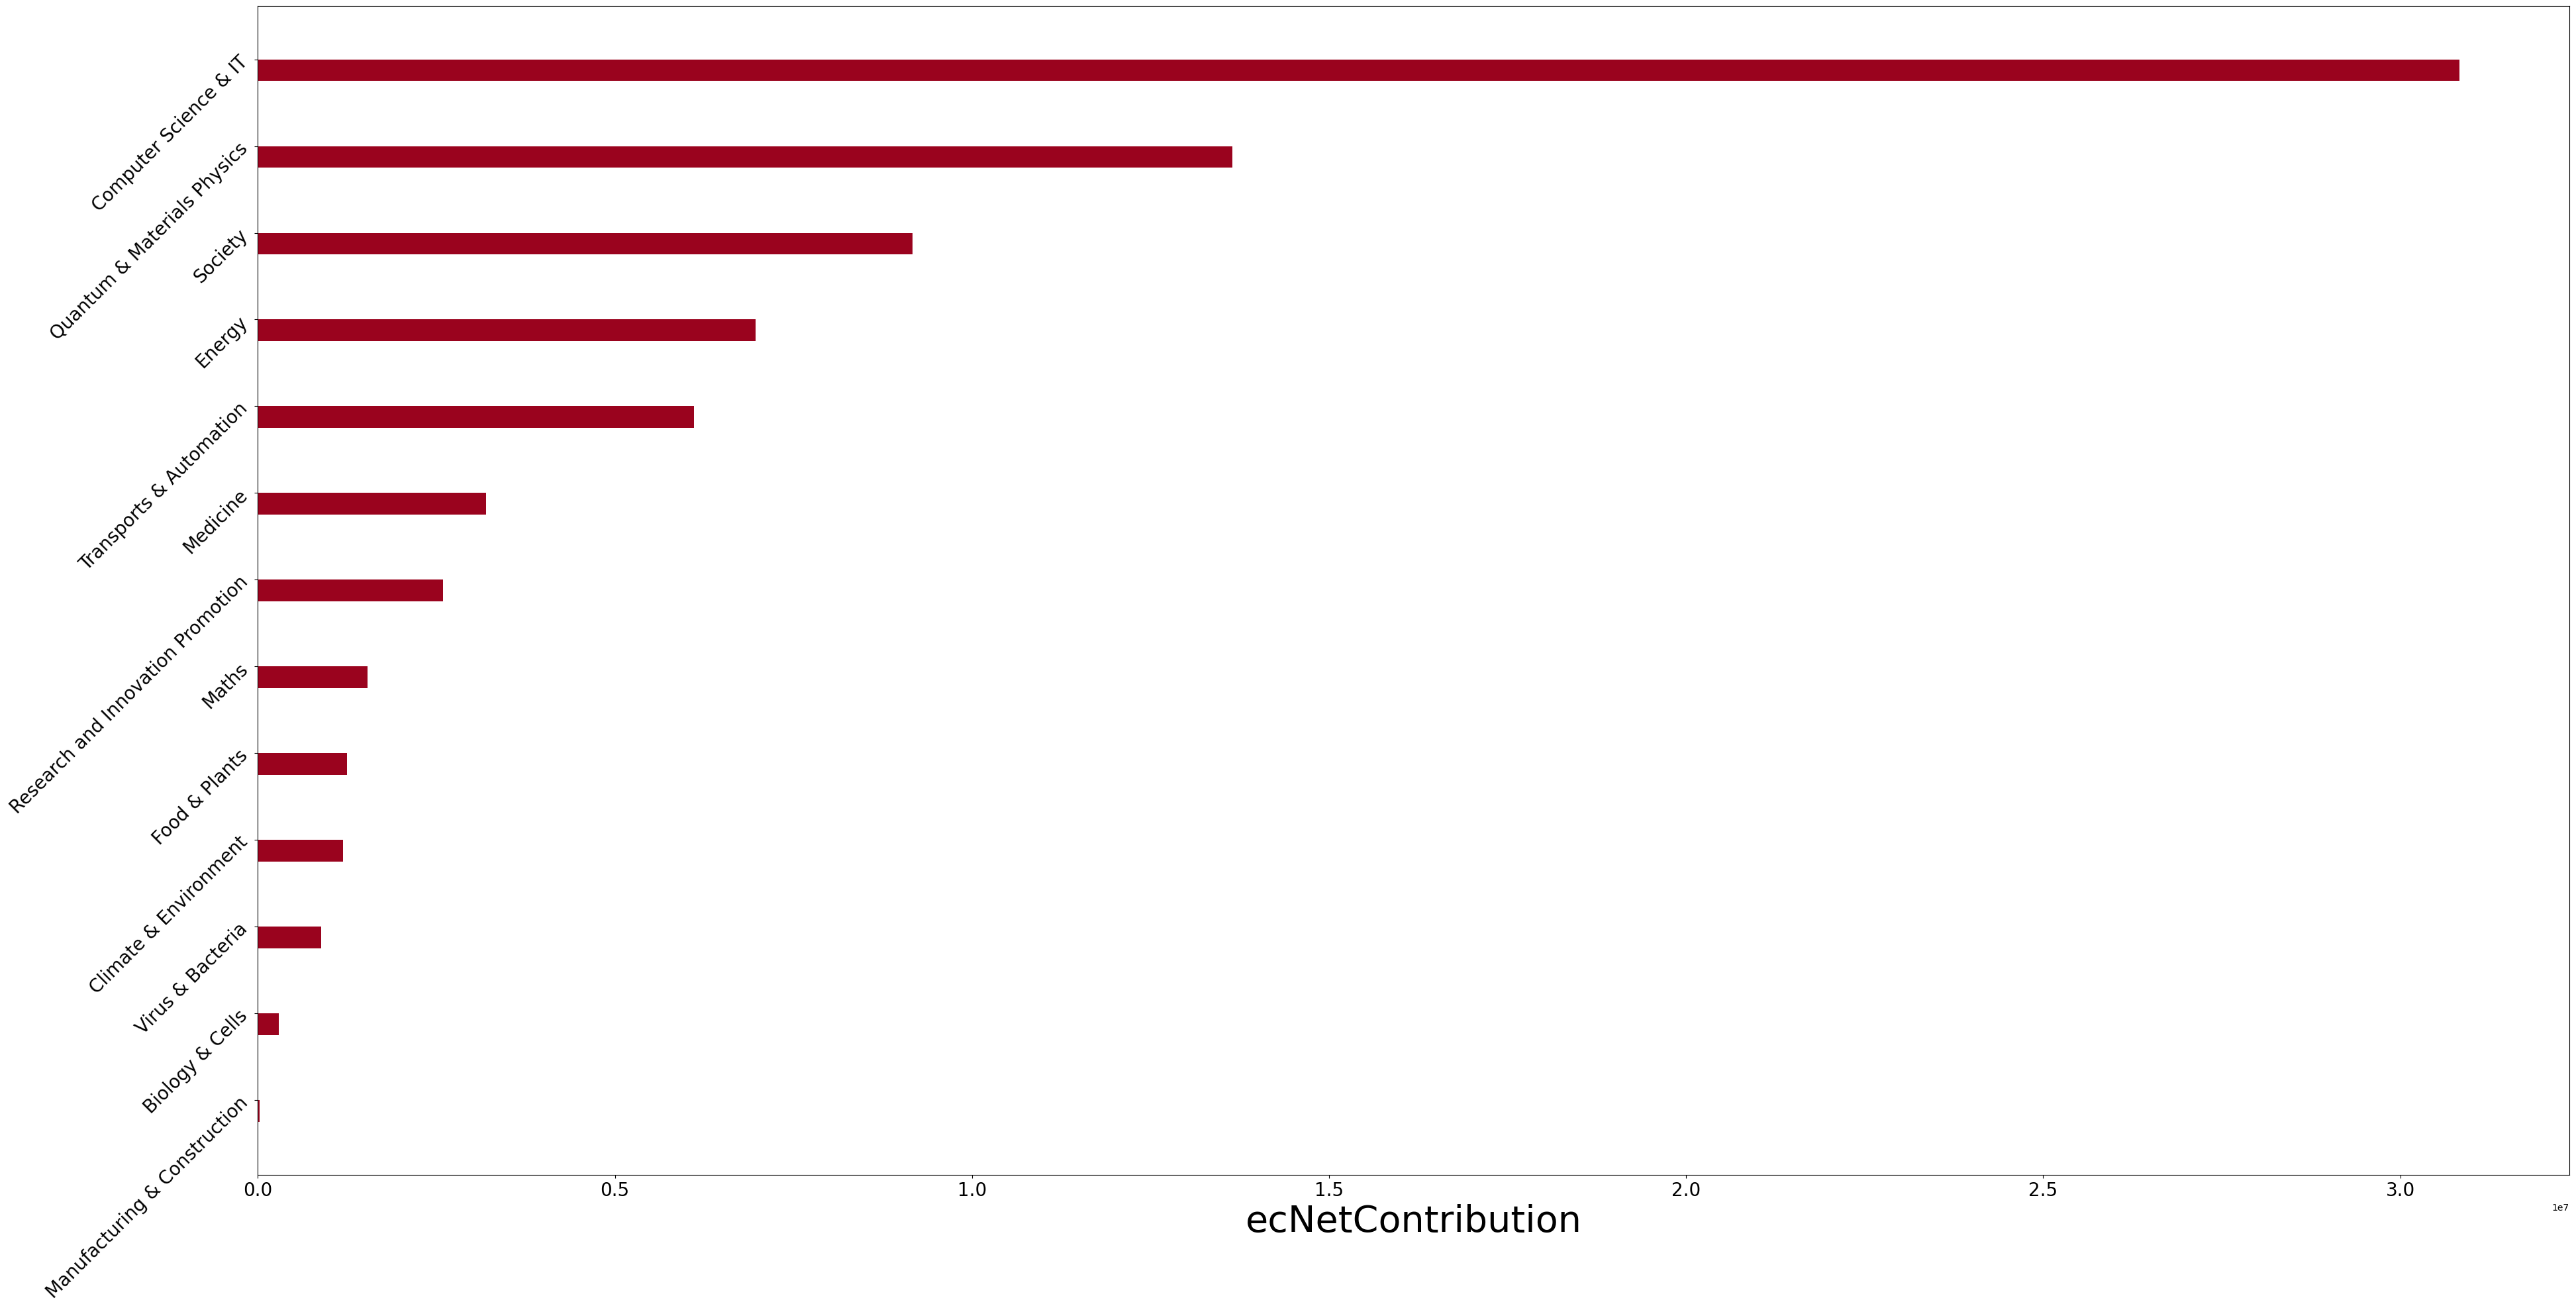

In [29]:
# barchart ecMaxContribution - topics h2020

df = fbk_money_tot

column_to_plot_1 = 'sum_ecNetContribution'

topics = list(df['topic_name']) #['Politics, economics\nsociety', 'Football\nsport', 'Religion', 'Nature, weather\nnatural disasters', 'Travelling, holidays\ntransportation', 'Food\ndrink', 'Music\nleisure', 'Education', 'Covid, vaccines\nhealth', 'Post photo', 'Dog\nanimal', 'Others']
topics = topics[::-1]
print(topics)

# bar width
bar_width = 0.25
img_size = (39, 20)
label_size = 40
ticks_size = 20

x1 = np.arange(len(topics))
x2 = [x + bar_width for x in x1]


y1 = list(df[column_to_plot_1])[::-1]

fig = plt.figure(figsize = img_size)

# creating the bar plot
plt.barh(x1, y1, color ='#9a031e', height = bar_width, label='ecNetContribution')

# extract handles and labels for the legend
handles, labels = plt.gca().get_legend_handles_labels()

plt.xlabel("ecNetContribution", fontsize=label_size)
plt.xticks(size=ticks_size)
plt.yticks([x + bar_width/2 for x in x1], topics, size=ticks_size, rotation=45)

plt.tight_layout()

#fig.savefig('FBK analysis/funding_topic_FBK_tot.png')

### Plot topics by org: pallogrammi

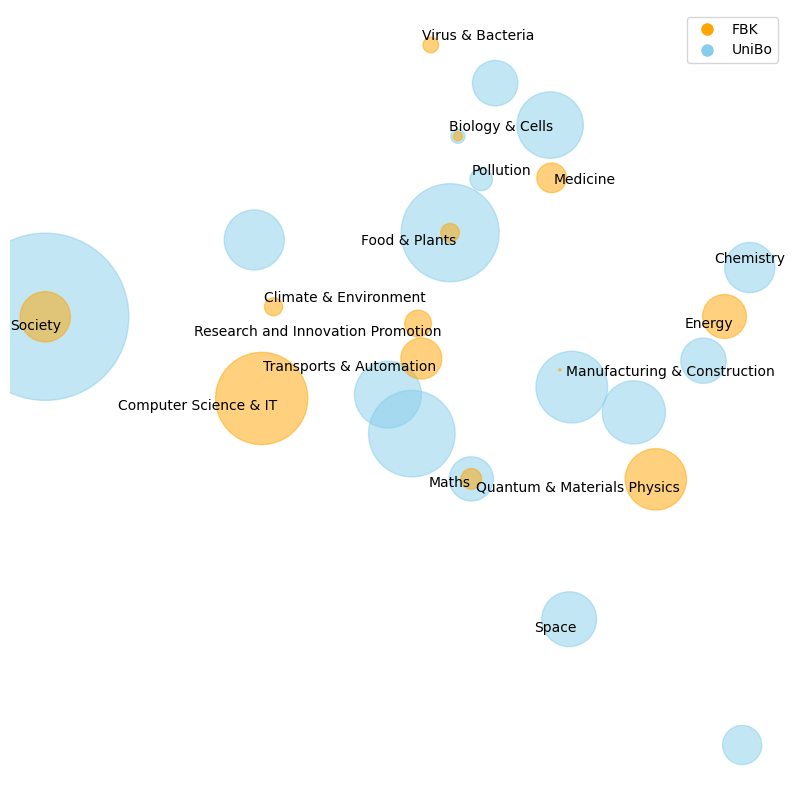

In [30]:
# org_df
org_df_1 = org_df_select_1
org_df_2 = org_df_select_2
org_df_list = [org_df_select_1, org_df_select_2]
colors = ['orange', 'skyblue']

# size of points column
size_col = 'sum_ecNetContribution' # count_proj

# legend labels
label_1 = 'FBK'
label_2 = 'UniBo'


fig, ax = plt.subplots(figsize=(10, 10))

i = 0

labels_df_tot = pd.concat([org_df_sorted_1, org_df_sorted_2])
labels_df = labels_df_tot[['topic_name', topic_num_col, 'mean_red_emb']].drop_duplicates(subset=['topic_name']).reset_index(drop=True)


org_df = org_df_list[1]
array_embeddings = np.array(list(org_df['mean_red_emb']))

topics_tot = list(org_df['topic_name'])
ax.scatter(array_embeddings[:, 0], array_embeddings[:, 1], c=colors[1], s=org_df[size_col]/7000, alpha=0.5)#cmap=colormap,  

org_df = org_df_list[0]
array_embeddings = np.array(list(org_df['mean_red_emb']))

topics_tot = list(org_df['topic_name'])

ax.scatter(array_embeddings[:, 0], array_embeddings[:, 1], c=colors[0], s=org_df[size_col]/7000, alpha=0.5)#cmap=colormap,  


mean_red_emb = np.array(list(labels_df['mean_red_emb']))
# text
xt = list(mean_red_emb[:, 0])
yt = list(mean_red_emb[:, 1])
t = list(labels_df['topic_name'])
# adjusttext
texts = [ax.text(xt[i], yt[i], t[i], ha='center', va='center', size=10, color='black') for i in range(len(xt))]
adjust_text(texts, ax=ax)
ax.axis('off')

# set legend characteristics
legend_handles = [
    mlines.Line2D([], [], color="orange", marker="o", linestyle="None", markersize=8, label=label_1),
    mlines.Line2D([], [], color="skyblue", marker="o", linestyle="None", markersize=8, label=label_2)
]

ax.legend(handles=legend_handles)

#fig.savefig('FBK analysis/contr_size ' + label_1 + ' - ' + label_2 + '.png')


## Group by topic, country and sum ecMaxContribution

### Grouped df topics: research, industry, total

In [32]:
# country col
country_col = 'country_code_original_nominatim' #macro_topic_name or Name

# df
df_8 = org_proj_tot_8 # org_proj_8 or df_topics_new_embeddings_8
df_9 = org_proj_tot_9 # org_proj_9 or df_topics_new_embeddings_9
df_tot = org_proj_tot # org_proj_tot or df_topics_new_embeddings
df_tot_res = org_proj_tot_res
df_tot_ind = org_proj_tot_ind

# topic name column
topic_name_col = 'macro_topic_name' #macro_topic_name or Name
# topic number col
topic_num_col = 'macro_topic' #macro_topic or topic_num_forced
df_8['netEcContribution'] = df_8['netEcContribution'].astype(float) #str.replace(',', '.').
df_grouped_money_8 = df_8.groupby([topic_num_col, country_col]).agg(sum_ecNetContribution=pd.NamedAgg(column='netEcContribution', aggfunc='sum'), count_proj=pd.NamedAgg(column='projectID', aggfunc='count'), topic_name=pd.NamedAgg(column=topic_name_col, aggfunc='first'), mean_red_emb_macro=pd.NamedAgg(column='mean_red_emb_macro', aggfunc='first')).reset_index()

# remove rows where ecMaxContribution is HORIZON.1.2 or HORIZON.3.2
df_9 = df_9[~df_9['netEcContribution'].isin(['participant'])]
df_9['netEcContribution'] = df_9['netEcContribution'].astype(float)#.str.replace(',', '.')
df_grouped_money_9 = df_9.groupby([topic_num_col, country_col]).agg(sum_ecNetContribution=pd.NamedAgg(column='netEcContribution', aggfunc='sum'), count_proj=pd.NamedAgg(column='projectID', aggfunc='count'), topic_name=pd.NamedAgg(column=topic_name_col, aggfunc='first'), mean_red_emb_macro=pd.NamedAgg(column='mean_red_emb_macro', aggfunc='first')).reset_index()


# DF TOT

df_tot = df_tot[~df_tot['netEcContribution'].isin(['participant'])]
df_tot['netEcContribution'] = df_tot['netEcContribution'].astype(float)#.str.replace(',', '.')
df_grouped_money_tot_country = df_tot.groupby([topic_num_col, country_col]).agg(sum_ecNetContribution=pd.NamedAgg(column='netEcContribution', aggfunc='sum'), count_proj=pd.NamedAgg(column='projectID', aggfunc='count'), topic_name=pd.NamedAgg(column=topic_name_col, aggfunc='first'), mean_red_emb_macro=pd.NamedAgg(column='mean_red_emb_macro', aggfunc='first')).reset_index()

# extract efat countries
df_grouped_money_tot_country_efta = df_grouped_money_tot_country[df_grouped_money_tot_country[country_col].isin(efta_countries)]

# add population info
pop_df = pd.read_csv(data_dir / 'population per year.csv')
pop_2023 = pop_df[['2023', 'Alpha-2 code']]
pop_2023 = pop_2023.rename(columns={'Alpha-2 code': country_col})
df_grouped_money_tot_country_efta[country_col] = df_grouped_money_tot_country_efta[country_col].str.upper()
df_grouped_money_tot_country_efta = pd.merge(df_grouped_money_tot_country_efta, pop_2023, on=country_col, how='left')
df_grouped_money_tot_country_efta['ecNetContribution per capita'] = df_grouped_money_tot_country_efta['sum_ecNetContribution'] / df_grouped_money_tot_country_efta['2023']
df_grouped_money_tot_country_efta['count_proj per capita'] = df_grouped_money_tot_country_efta['count_proj'] / df_grouped_money_tot_country_efta['2023']

df_grouped_money_tot_country_efta[country_col] = df_grouped_money_tot_country_efta[country_col].str.lower()


# DF TOT RES

df_tot_res = df_tot_res[~df_tot_res['netEcContribution'].isin(['participant'])]
df_tot_res['netEcContribution'] = df_tot_res['netEcContribution'].astype(float)#.str.replace(',', '.')
df_grouped_money_tot_country_res = df_tot_res.groupby([topic_num_col, country_col]).agg(sum_ecNetContribution=pd.NamedAgg(column='netEcContribution', aggfunc='sum'), count_proj=pd.NamedAgg(column='projectID', aggfunc='count'), topic_name=pd.NamedAgg(column=topic_name_col, aggfunc='first'), mean_red_emb_macro=pd.NamedAgg(column='mean_red_emb_macro', aggfunc='first')).reset_index()

# extract efat countries
df_grouped_money_tot_country_efta_res = df_grouped_money_tot_country_res[df_grouped_money_tot_country_res[country_col].isin(efta_countries)]

# add population info
pop_df = pd.read_csv(data_dir / 'population per year.csv')
pop_2023 = pop_df[['2023', 'Alpha-2 code']]
pop_2023 = pop_2023.rename(columns={'Alpha-2 code': country_col})
df_grouped_money_tot_country_efta_res[country_col] = df_grouped_money_tot_country_efta_res[country_col].str.upper()
df_grouped_money_tot_country_efta_res = pd.merge(df_grouped_money_tot_country_efta_res, pop_2023, on=country_col, how='left')
df_grouped_money_tot_country_efta_res['ecNetContribution per capita'] = df_grouped_money_tot_country_efta_res['sum_ecNetContribution'] / df_grouped_money_tot_country_efta_res['2023']
df_grouped_money_tot_country_efta_res['count_proj per capita'] = df_grouped_money_tot_country_efta_res['count_proj'] / df_grouped_money_tot_country_efta_res['2023']
df_grouped_money_tot_country_efta_res[country_col] = df_grouped_money_tot_country_efta_res[country_col].str.lower()


# DF TOT IND

df_tot_ind = df_tot_ind[~df_tot_ind['netEcContribution'].isin(['participant'])]
df_tot_ind['netEcContribution'] = df_tot_ind['netEcContribution'].astype(float)#.str.replace(',', '.')
df_grouped_money_tot_country_ind = df_tot_ind.groupby([topic_num_col, country_col]).agg(sum_ecNetContribution=pd.NamedAgg(column='netEcContribution', aggfunc='sum'), count_proj=pd.NamedAgg(column='projectID', aggfunc='count'), topic_name=pd.NamedAgg(column=topic_name_col, aggfunc='first'), mean_red_emb_macro=pd.NamedAgg(column='mean_red_emb_macro', aggfunc='first')).reset_index()

# extract efat countries
df_grouped_money_tot_country_efta_ind = df_grouped_money_tot_country_ind[df_grouped_money_tot_country_ind[country_col].isin(efta_countries)]

# add population info
pop_df = pd.read_csv(data_dir / 'population per year.csv')
pop_2023 = pop_df[['2023', 'Alpha-2 code']]
pop_2023 = pop_2023.rename(columns={'Alpha-2 code': country_col})
df_grouped_money_tot_country_efta_ind[country_col] = df_grouped_money_tot_country_efta_ind[country_col].str.upper()
df_grouped_money_tot_country_efta_ind = pd.merge(df_grouped_money_tot_country_efta_ind, pop_2023, on=country_col, how='left')
df_grouped_money_tot_country_efta_ind['ecNetContribution per capita'] = df_grouped_money_tot_country_efta_ind['sum_ecNetContribution'] / df_grouped_money_tot_country_efta_ind['2023']
df_grouped_money_tot_country_efta_ind['count_proj per capita'] = df_grouped_money_tot_country_efta_ind['count_proj'] / df_grouped_money_tot_country_efta_ind['2023']
df_grouped_money_tot_country_efta_ind[country_col] = df_grouped_money_tot_country_efta_ind[country_col].str.lower()

/tmp/ipykernel_521596/712015908.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_8['netEcContribution'] = df_8['netEcContribution'].astype(float) #str.replace(',', '.').
/tmp/ipykernel_521596/712015908.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_9['netEcContribution'] = df_9['netEcContribution'].astype(float)#.str.replace(',', '.')
/tmp/ipykernel_521596/712015908.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,c

### Plot topics by country: pallogrammi

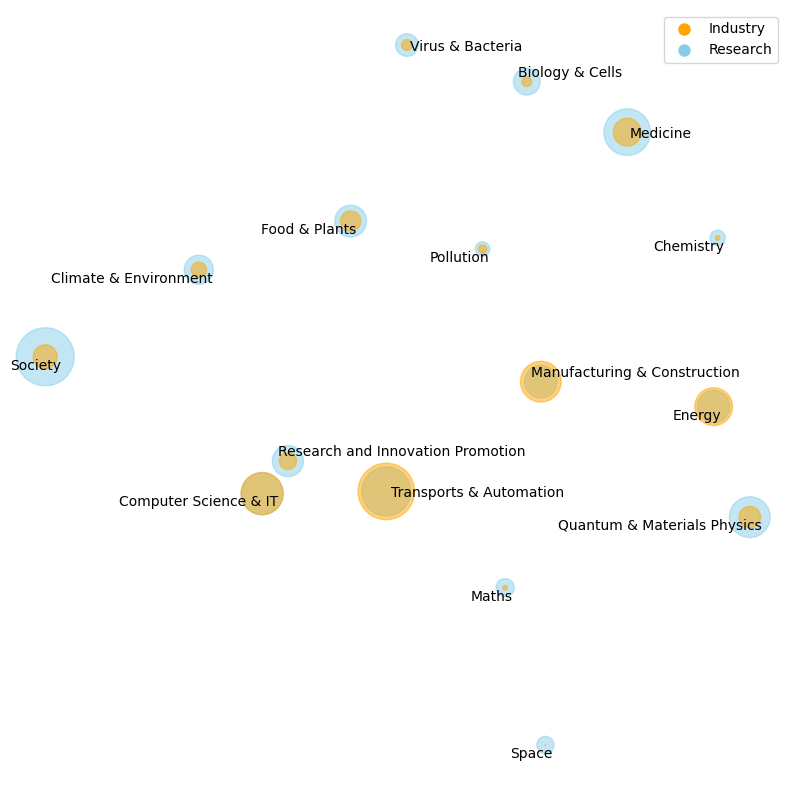

In [33]:
country = 'it'
country_col = 'country_code_original_nominatim'

country_df_select_1_res = df_grouped_money_tot_country_efta_res[df_grouped_money_tot_country_efta_res[country_col] == country]
country_df_select_1_ind = df_grouped_money_tot_country_efta_ind[df_grouped_money_tot_country_efta_ind[country_col] == country]

# org_df
country_df_1 = country_df_select_1_ind
country_df_2 = country_df_select_1_res
country_df_list = [country_df_1, country_df_2]
colors = ['orange', 'skyblue']

size_col = 'ecNetContribution per capita' # sum_ecNetContribution

# legend labels
label_1 = 'Industry'
label_2 = 'Research'

# 
macro_topics_centres_col = 'mean_red_emb_macro'


fig, ax = plt.subplots(figsize=(10, 10))


labels_df_tot = pd.concat([country_df_select_1_ind, country_df_select_1_res])
labels_df = labels_df_tot[['topic_name', topic_num_col, macro_topics_centres_col]].drop_duplicates(subset=['topic_name']).reset_index(drop=True)


country_df_2 = country_df_list[1]
array_embeddings = np.array(list(country_df_2[macro_topics_centres_col]))

topics_tot = list(country_df_2['topic_name'])

ax.scatter(array_embeddings[:, 0], array_embeddings[:, 1], c=colors[1], s=country_df_2[size_col]*100, alpha=0.5)#cmap=colormap,  /700000


country_df_1 = country_df_list[0]
array_embeddings = np.array(list(country_df_1[macro_topics_centres_col]))

topics_tot = list(country_df_1['topic_name'])

ax.scatter(array_embeddings[:, 0], array_embeddings[:, 1], c=colors[0], s=country_df_1[size_col]*100, alpha=0.5)#cmap=colormap,  /700000

 

mean_red_emb = np.array(list(labels_df[macro_topics_centres_col]))

# text
xt = list(mean_red_emb[:, 0])
yt = list(mean_red_emb[:, 1])

t = list(labels_df['topic_name'])
# adjusttext
texts = [ax.text(xt[i], yt[i], t[i], ha='center', va='center', size=10, color='black') for i in range(len(xt))]
adjust_text(texts, ax=ax)
ax.axis('off')

# set legend characteristics
legend_handles = [
    mlines.Line2D([], [], color="orange", marker="o", linestyle="None", markersize=8, label=label_1),
    mlines.Line2D([], [], color="skyblue", marker="o", linestyle="None", markersize=8, label=label_2)
]

ax.legend(handles=legend_handles)

#fig.savefig('FBK analysis/country analysis/contr_size ' + label_1 + ' - ' + label_2 + '_ITALY.png')


### For each topic, compute fraction of tot and per capita money

In [34]:
#grouping column
contr_tot_col = 'sum_ecNetContribution'
contr_capita_col = 'ecNetContribution per capita'

# list countries
efta_list = list(efta_df['country'].str.lower())
country_list = sorted(efta_list) #['it', 'es', 'fr', 'de', 'pl']


topic_col = 'topic_name'

df_sorted_topic = df_grouped_money_tot_country_efta_res[[topic_col]].drop_duplicates().sort_values(by=topic_col)

country_research_df = pd.DataFrame()
country_industry_df = pd.DataFrame()
country_tot_df = pd.DataFrame()

for topic in df_sorted_topic[topic_col]:

    # research
    df_topic_res = df_grouped_money_tot_country_efta_res[df_grouped_money_tot_country_efta_res[topic_col] == topic]#.sort_values(by='topic_name')
    # ecNetContr tot
    df_topic_res[contr_tot_col + '_frac'] = df_topic_res[contr_tot_col] / df_topic_res[contr_tot_col].sum()
    # ecNetContr capita
    df_topic_res[contr_capita_col + '_frac'] = df_topic_res[contr_capita_col] / df_topic_res[contr_capita_col].sum()
    country_research_df = pd.concat([country_research_df, df_topic_res])

    # industry
    df_topic_ind = df_grouped_money_tot_country_efta_ind[df_grouped_money_tot_country_efta_ind[topic_col] == topic]#.sort_values(by='topic_name')
    # ecNetContr tot
    df_topic_ind[contr_tot_col + '_frac'] = df_topic_ind[contr_tot_col] / df_topic_ind[contr_tot_col].sum()
    # ecNetContr capita
    df_topic_ind[contr_capita_col + '_frac'] = df_topic_ind[contr_capita_col] / df_topic_ind[contr_capita_col].sum()
    country_industry_df = pd.concat([country_industry_df, df_topic_ind])

    # tot
    df_topic = df_grouped_money_tot_country_efta[df_grouped_money_tot_country_efta[topic_col] == topic]#.sort_values(by='topic_name')
    # ecNetContr tot
    df_topic[contr_tot_col + '_frac'] = df_topic[contr_tot_col] / df_topic[contr_tot_col].sum()
    # ecNetContr capita
    df_topic[contr_capita_col + '_frac'] = df_topic[contr_capita_col] / df_topic[contr_capita_col].sum()
    country_tot_df = pd.concat([country_tot_df, df_topic])


/tmp/ipykernel_521596/2717112509.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_topic_res[contr_tot_col + '_frac'] = df_topic_res[contr_tot_col] / df_topic_res[contr_tot_col].sum()
/tmp/ipykernel_521596/2717112509.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_topic_res[contr_capita_col + '_frac'] = df_topic_res[contr_capita_col] / df_topic_res[contr_capita_col].sum()
/tmp/ipykernel_521596/2717112509.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Da

## Research VS industry

In [35]:
# merge research and industry df

country_res_ind_df = pd.merge(country_research_df, country_industry_df, on=['topic_name', 'country_code_original_nominatim'], how='outer')
country_res_ind_df = country_res_ind_df.fillna(0)

### Indicator ecNetContribution per capita in specific country: res vs ind -> res-ind / res+ind

/tmp/ipykernel_521596/702463193.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_res_ind_it['r_i_sum'] = df_res_ind_it['ecNetContribution per capita_x'] + df_res_ind_it['ecNetContribution per capita_y']
/tmp/ipykernel_521596/702463193.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_res_ind_it['r_i_diff'] = df_res_ind_it['ecNetContribution per capita_x'] - df_res_ind_it['ecNetContribution per capita_y']
/tmp/ipykernel_521596/702463193.py:9: SettingWithCopyWarning: 
A value is trying to be set on

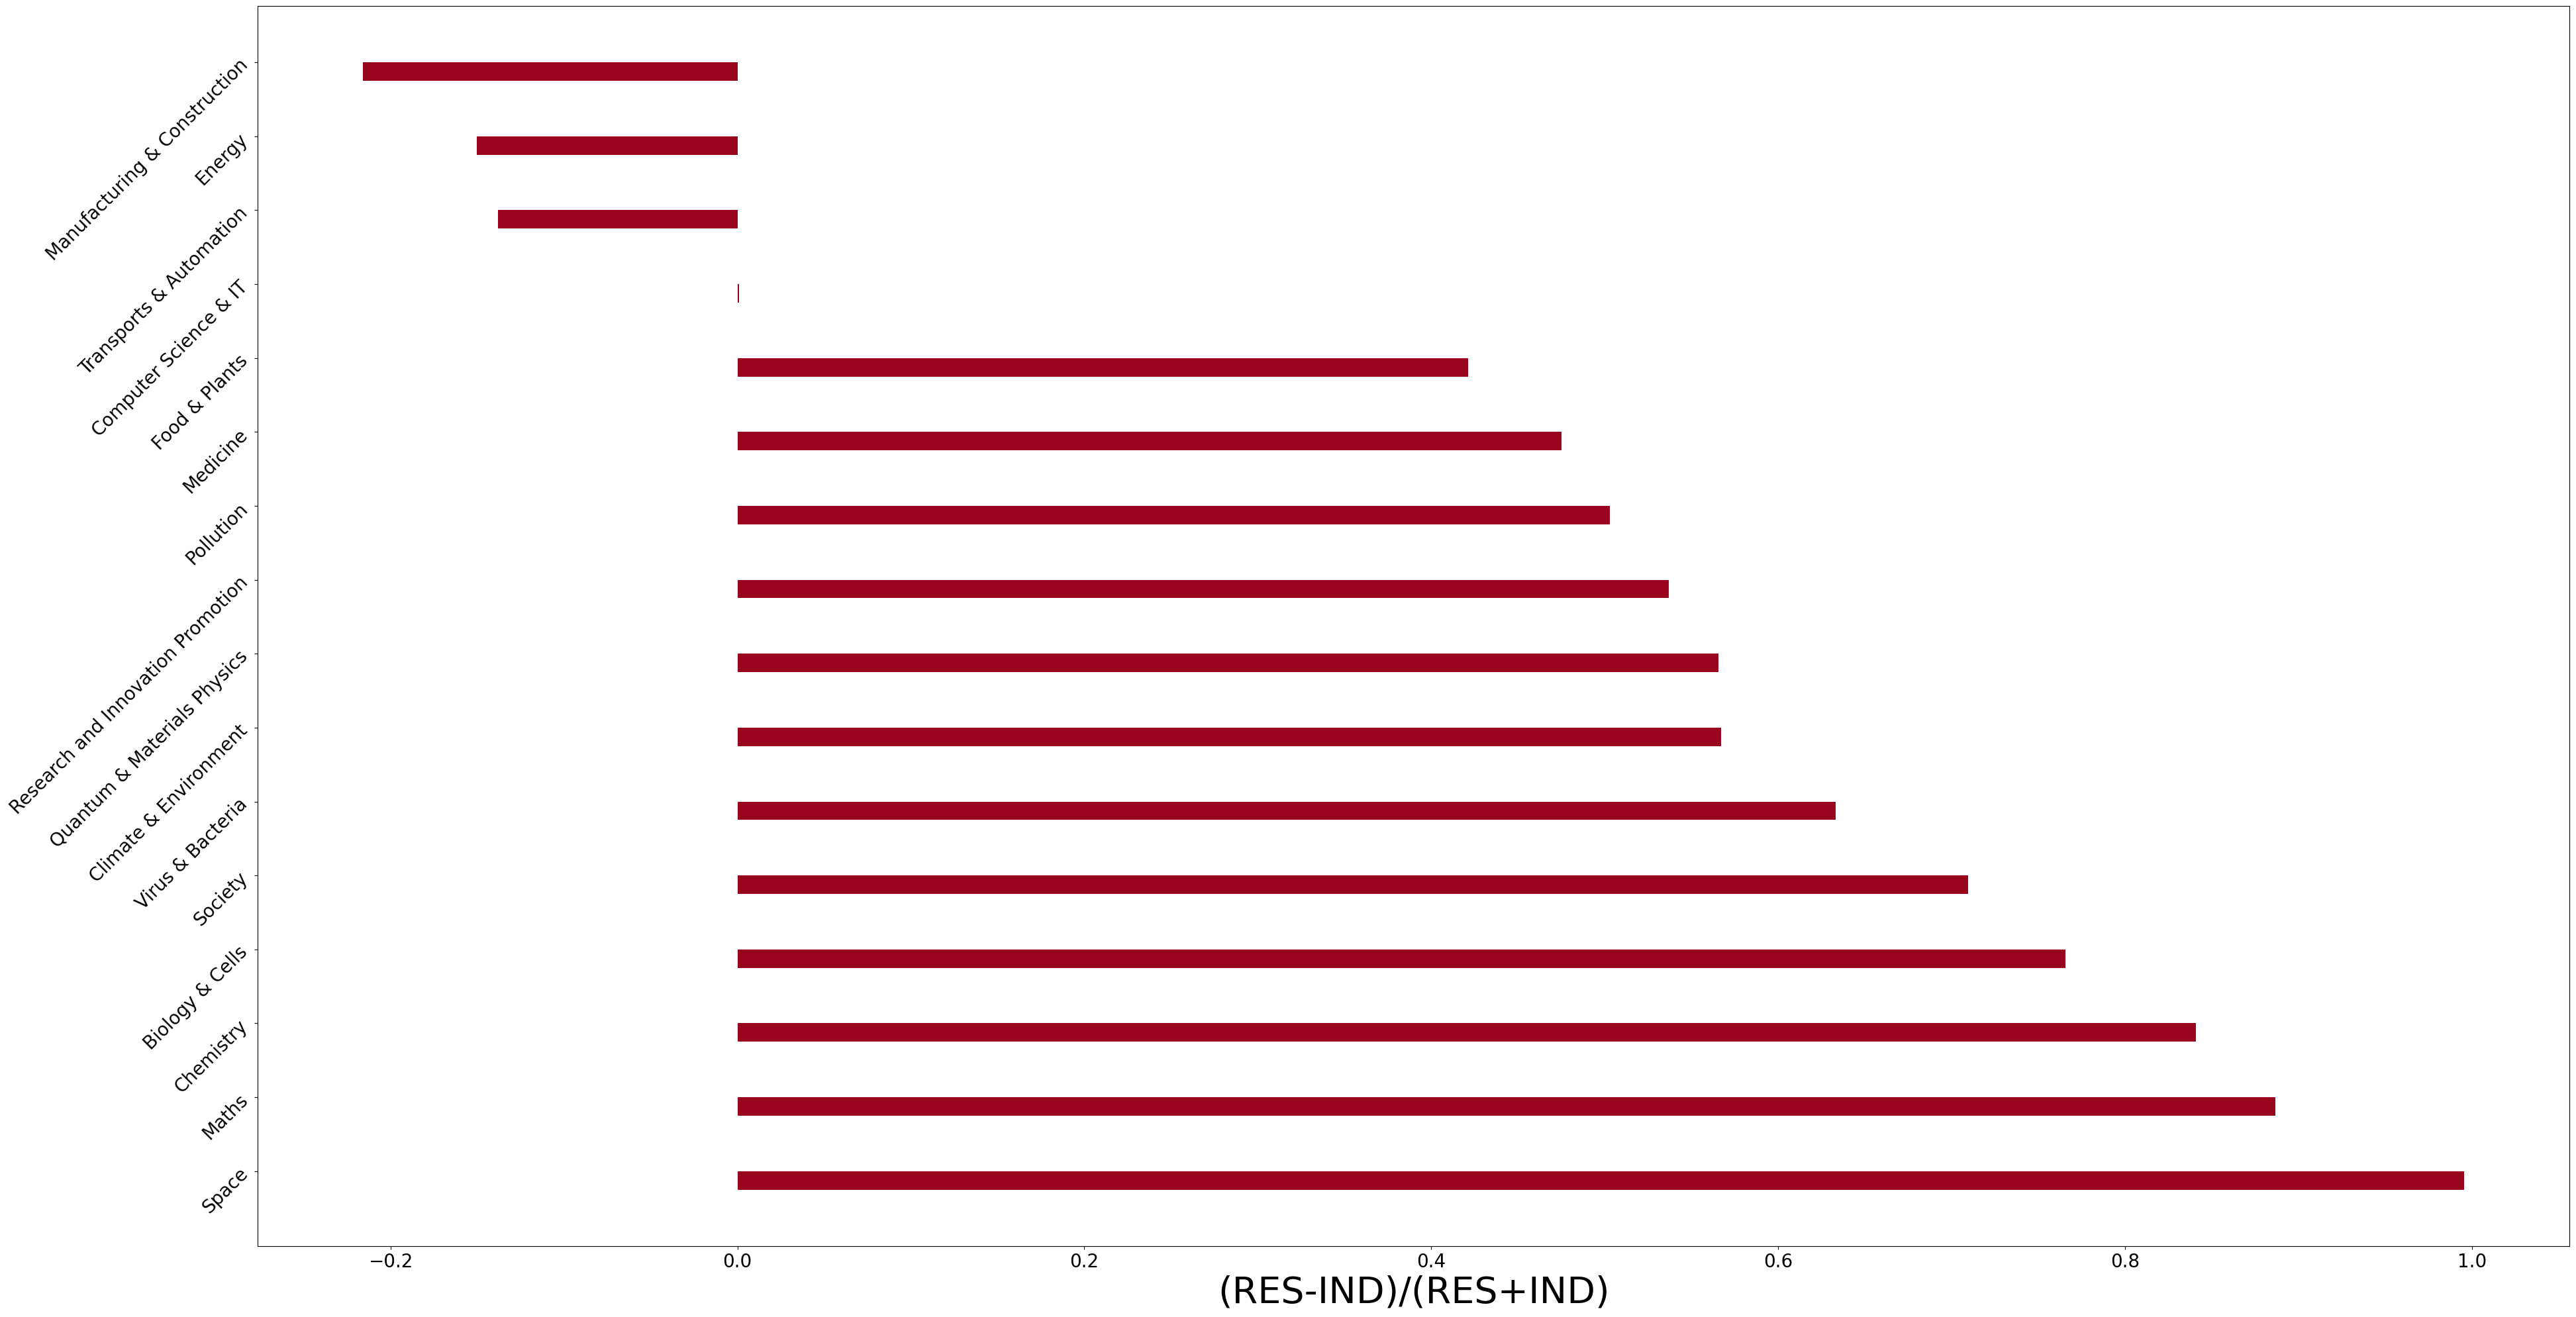

In [36]:
# quantify ecNetContribution per capita in specific country res-ind / res+ind

# chosen country
country = 'it'

df_res_ind_it = country_res_ind_df[country_res_ind_df['country_code_original_nominatim'] == country]
df_res_ind_it['r_i_sum'] = df_res_ind_it['ecNetContribution per capita_x'] + df_res_ind_it['ecNetContribution per capita_y']
df_res_ind_it['r_i_diff'] = df_res_ind_it['ecNetContribution per capita_x'] - df_res_ind_it['ecNetContribution per capita_y']
df_res_ind_it['res_ind_index'] = df_res_ind_it['r_i_diff'] / df_res_ind_it['r_i_sum']

df_res_ind_it = df_res_ind_it.sort_values(by='res_ind_index')

topics = list(df_res_ind_it['topic_name']) #['Politics, economics\nsociety', 'Football\nsport', 'Religion', 'Nature, weather\nnatural disasters', 'Travelling, holidays\ntransportation', 'Food\ndrink', 'Music\nleisure', 'Education', 'Covid, vaccines\nhealth', 'Post photo', 'Dog\nanimal', 'Others']
topics = topics[::-1]

# bar width
bar_width = 0.25
img_size = (39, 20)
label_size = 40
ticks_size = 20

x1 = np.arange(len(topics))
x2 = [x + bar_width for x in x1]

y1 = list(df_res_ind_it['res_ind_index'])[::-1]

fig = plt.figure(figsize = img_size)

# creating the bar plot
plt.barh(x1, y1, color ='#9a031e', height = bar_width, label='ecNetContribution')

# extract handles and labels for the legend
handles, labels = plt.gca().get_legend_handles_labels()

plt.xlabel("(RES-IND)/(RES+IND)", fontsize=label_size)
plt.xticks(size=ticks_size)
plt.yticks([x + bar_width/2 for x in x1], topics, size=ticks_size, rotation=45)

plt.tight_layout()

#plt.savefig('FBK analysis/res_ind_topics_' + country + '.png')

### Plot money in res vs ind, compute pearson and spearman correlation per country where vector is the money for each topic

/tmp/ipykernel_521596/1135444851.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[country_col] = df[country_col].str.upper()


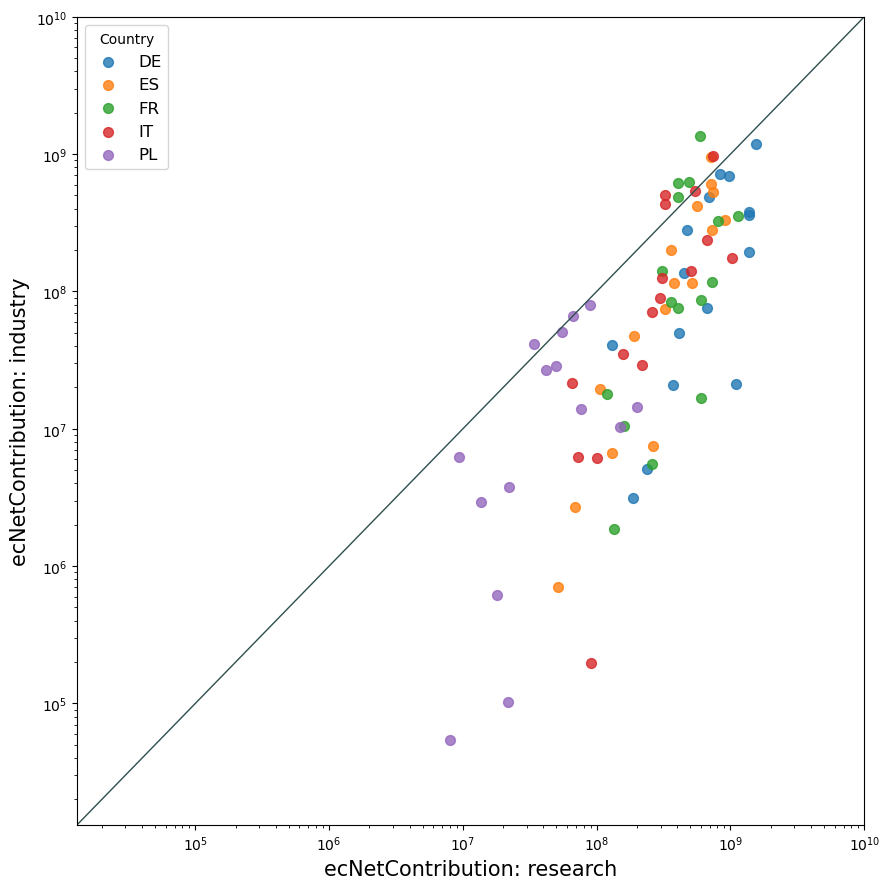

"ax.scatter(country_res_ind_df[x_col], country_res_ind_df[y_col])\n\nxt = list(country_res_ind_df[x_col].values)\nyt = list(country_res_ind_df[y_col].values)\nt = list(country_res_ind_df[country_col].values)\ntexts = [ax.text(xt[i], yt[i], t[i], ha='left', va='bottom', size=10, color='black') for i in range(len(xt))]"

In [37]:
# plot money in res VS industry

# embeddings type
emb_type = 'BGE' # paraphrase

country_col = 'country_code_original_nominatim'

country_list_plot = ['it', 'de', 'fr', 'es', 'pl']
df = country_res_ind_df[country_res_ind_df[country_col].isin(country_list_plot)]
df[country_col] = df[country_col].str.upper()

plot_type = 'ecNetContr'  # # #'ecNetContr_capita' 'ecNetContr_capita_frac' 'ecNetContr_frac'

if plot_type == 'ecNetContr':
    x_col = 'sum_ecNetContribution_x'
    y_col = 'sum_ecNetContribution_y'
    x_label = 'ecNetContribution: research'
    y_label = 'ecNetContribution: industry'
elif plot_type == 'ecNetContr_capita':
    x_col = 'ecNetContribution per capita_x'
    y_col = 'ecNetContribution per capita_y'
    x_label = 'ecNetContribution per capita: research'
    y_label = 'ecNetContribution per capita: industry'
elif plot_type == 'ecNetContr_frac':
    x_col = 'sum_ecNetContribution_frac_x'
    y_col = 'sum_ecNetContribution_frac_y'
    x_label = 'Fraction ecNetContribution: research'
    y_label = 'Fraction ecNetContribution: industry'
elif plot_type == 'ecNetContr_capita_frac':
    x_col = 'ecNetContribution per capita_frac_x'
    y_col = 'ecNetContribution per capita_frac_y'
    x_label = 'Fraction ecNetContribution per capita: research'
    y_label = 'Fraction ecNetContribution per capita: industry'


categories = df[country_col].unique()
cmap = plt.get_cmap("tab10")
color_map = {cat: cmap(i) for i, cat in enumerate(categories)}

fig, ax = plt.subplots(figsize=(9,9))

for cat in categories:
    subset = df[df[country_col] == cat]
    ax.scatter(
        subset[x_col],
        subset[y_col],
        color=color_map[cat],
        label=cat,
        s=50,
        alpha=0.8
    )

# diagonal
low_bound = 13000 #0.01
high_bound = 10000000000 #100
x = np.linspace(low_bound, high_bound, 10)

ax.plot(x, x, color='darkslategray', alpha=1, linewidth=1.0)
ax.set_xlim(low_bound, high_bound)
ax.set_ylim(low_bound, high_bound)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(x_label, fontsize=15)
ax.set_ylabel(y_label, fontsize=15)
ax.legend(title="Country", fontsize=12)

fig.tight_layout()

plt.show()


corr_df_pearson = pd.DataFrame()
corr_df_spearman = pd.DataFrame()

for country in country_list:
    if country != 'li':
        df_country = country_res_ind_df[country_res_ind_df[country_col] == country]
        spearman_corr = scipy.stats.spearmanr(df_country[x_col], df_country[y_col])
        pearson_corr = scipy.stats.pearsonr(df_country[x_col], df_country[y_col])
        corr_df_pearson = corr_df_pearson._append({'country': country, 'pearson corr res-ind': pearson_corr[0], 'p-value': pearson_corr[1]}, ignore_index=True)
        corr_df_spearman = corr_df_spearman._append({'country': country, 'spearman corr res-ind': spearman_corr[0], 'p-value': spearman_corr[1]}, ignore_index=True)


# macro-topic manual (only for BGE)
'''fig.savefig('research vs industry/correlation res-ind figures ' + emb_type + '/' + plot_type + '_manual.png')
corr_df_pearson.to_csv('research vs industry/correlation res-ind ' + emb_type + '/' + plot_type + '_pearson_manual.csv')
corr_df_spearman.to_csv('research vs industry/correlation res-ind ' + emb_type + '/' + plot_type + '_spearman_manual.csv')'''

# macro-topic semi-manual
'''fig.savefig('research vs industry/correlation res-ind figures ' + emb_type + '/' + plot_type + '.png')
corr_df_pearson.to_csv('research vs industry/correlation res-ind ' + emb_type + '/' + plot_type + '_pearson.csv')
corr_df_spearman.to_csv('research vs industry/correlation res-ind ' + emb_type + '/' + plot_type + '_spearman.csv')
'''

'''ax.scatter(country_res_ind_df[x_col], country_res_ind_df[y_col])

xt = list(country_res_ind_df[x_col].values)
yt = list(country_res_ind_df[y_col].values)
t = list(country_res_ind_df[country_col].values)
texts = [ax.text(xt[i], yt[i], t[i], ha='left', va='bottom', size=10, color='black') for i in range(len(xt))]'''

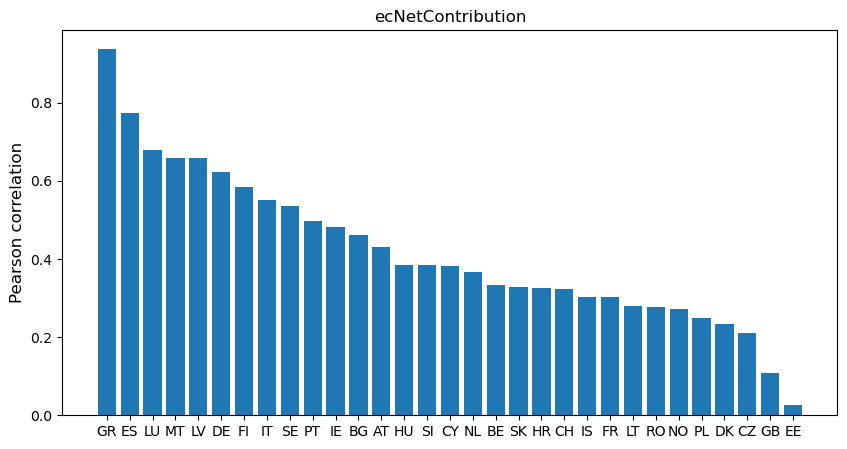

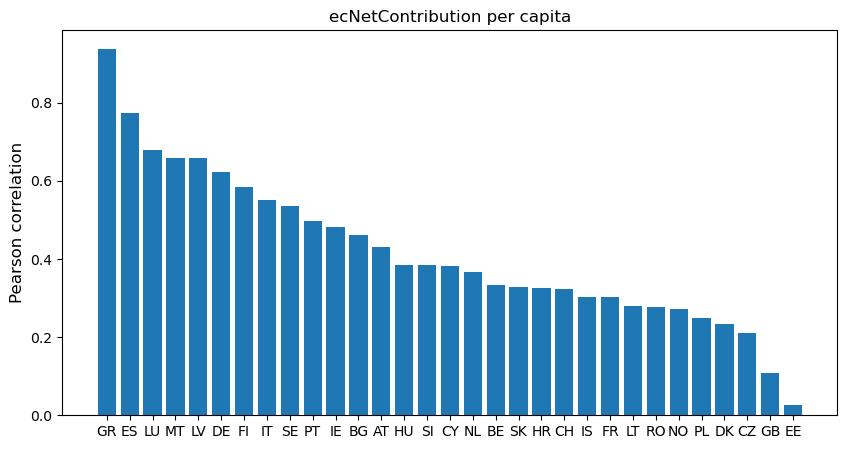

"fig, ax = plt.subplots(figsize=(10,5))\nax.bar(df_ecNetContr_capita_frac['country'], df_ecNetContr_capita_frac['spearman corr res-ind'])\nax.set_ylabel('Spearman correlation')\nax.set_title('ecNetContribution per capita fraction')\nplt.show()"

In [38]:
# plot correlation

# embeddings type
emb_type = 'BGE' # paraphrase

# correlation type: pearson or spearman
corr_type = 'pearson'
corr_plot = 'Pearson'

# read df

# ecNetContr
# manual macro-topics (only for BGE)
df_ecNetContr = pd.read_csv('research vs industry/correlation res-ind ' + emb_type + '/ecNetContr_' + corr_type + '_manual.csv').sort_values(by=corr_type + ' corr res-ind', ascending=False)
# semi-manula macro-topics
#df_ecNetContr = pd.read_csv('research vs industry/correlation res-ind ' + emb_type + '/ecNetContr_' + corr_type + '.csv').sort_values(by=corr_type + ' corr res-ind', ascending=False)

# ecNetContr capita
# manual macro-topics (only for BGE)
df_ecNetContr_capita = pd.read_csv('research vs industry/correlation res-ind ' + emb_type + '/ecNetContr_capita_' + corr_type + '_manual.csv').sort_values(by=corr_type + ' corr res-ind', ascending=False)
# semi_manual macro-topics
#df_ecNetContr_capita = pd.read_csv('research vs industry/correlation res-ind ' + emb_type + '/ecNetContr_capita_' + corr_type + '.csv').sort_values(by=corr_type + ' corr res-ind', ascending=False)

# ecNetContr frac
#df_ecNetContr_frac = pd.read_csv('research vs industry/correlation res-ind/ecNetContr_frac.csv').sort_values(by='spearman corr res-ind', ascending=False)
# ecNetContr capita frac
#df_ecNetContr_capita_frac = pd.read_csv('research vs industry/correlation res-ind/ecNetContr_capita_frac.csv').sort_values(by='spearman corr res-ind', ascending=False)

# plot
fig, ax = plt.subplots(figsize=(10,5))
ax.bar(df_ecNetContr['country'].str.upper(), df_ecNetContr[corr_type + ' corr res-ind'])
ax.set_ylabel(corr_plot + ' correlation', fontsize=12)
ax.set_title('ecNetContribution')
plt.show()
#fig.savefig('research vs industry/correlation res-ind figures ' + emb_type + '/ecNetContribution_' + corr_type + '.png')

fig, ax = plt.subplots(figsize=(10,5))
ax.bar(df_ecNetContr_capita['country'].str.upper(), df_ecNetContr_capita[corr_type + ' corr res-ind'])
ax.set_ylabel(corr_plot + ' correlation', fontsize=12)
ax.set_title('ecNetContribution per capita')
plt.show()
#fig.savefig('research vs industry/correlation res-ind figures ' + emb_type + '/ecNetContribution per capita_' + corr_type + '.png')

'''fig, ax = plt.subplots(figsize=(10,5))
ax.bar(df_ecNetContr_frac['country'], df_ecNetContr_frac['spearman corr res-ind'])
ax.set_ylabel('Spearman correlation')
ax.set_title('ecNetContribution fraction')
plt.show()'''

'''fig, ax = plt.subplots(figsize=(10,5))
ax.bar(df_ecNetContr_capita_frac['country'], df_ecNetContr_capita_frac['spearman corr res-ind'])
ax.set_ylabel('Spearman correlation')
ax.set_title('ecNetContribution per capita fraction')
plt.show()'''

### Correlation matrix

In [39]:
country_col = 'country_code_original_nominatim'
grouping_col = 'ecNetContribution per capita'  # 'sum_ecNetContribution'

# set True if we want to use subset of countries for clarity in the visualization of correlation matrix
reduced_countries = True
#select countries to visualize
if reduced_countries:
    country_list_corr = ['de', 'gb', 'fr', 'it', 'es',  'pl', 'ro', 'nl']
else:
    country_list_corr = country_list

dict_country_res = {}
dict_country_ind = {}
dict_country_tot = {}



for country in country_list_corr:

    # research
    country_res = country_research_df[country_research_df[country_col] == country].sort_values(by='topic_name')
    country_res = pd.merge(df_sorted_topic, country_res, on='topic_name', how='left')
    country_res[grouping_col] = country_res[grouping_col].fillna(0)
    #print(country_res)
    # industry
    country_ind = country_industry_df[country_industry_df[country_col] == country]
    country_ind = pd.merge(df_sorted_topic, country_ind, on='topic_name', how='left')
    country_ind[grouping_col] = country_ind[grouping_col].fillna(0)
    # tot
    country_tot = country_tot_df[country_tot_df[country_col] == country]
    country_tot = pd.merge(df_sorted_topic, country_tot, on='topic_name', how='left')
    country_tot[grouping_col] = country_tot[grouping_col].fillna(0)

    dict_country_res[country] = np.array(list(country_res[grouping_col]))
    #print(dict_country_res)
    dict_country_ind[country] = np.array(list(country_ind[grouping_col]))
    dict_country_tot[country] = np.array(list(country_tot[grouping_col]))


countries_res = dict_country_res.keys()
countries_ind = dict_country_ind.keys()
topics_res = dict_country_res.values()
topics_ind = dict_country_ind.values()

country_topic_res = list(zip(countries_res, topics_res))
country_topic_ind = list(zip(countries_ind, topics_ind))



# Generate all unordered pairs
pairs_res = []

for (label1, list1), (label2, list2) in combinations(country_topic_res, 2):
    pairs_res.append({
        "label_pair": (label1, label2),
        "list_pair": (list1, list2)
    })


# Generate all unordered pairs
pairs_ind = []

for (label1, list1), (label2, list2) in combinations(country_topic_ind, 2):
    pairs_ind.append({
        "label_pair": (label1, label2),
        "list_pair": (list1, list2)
    })

In [40]:
# research

for el in pairs_res:
    
    # jensen-shannon divergence
    
    # extract vectors
    country1 = np.array(el['list_pair'][0])
    country2 = np.array(el['list_pair'][1])


    #normalize to probability distributions
    #if (country1.sum() != 0) and (country2.sum() != 0):
    p = country1 / country1.sum()
    q = country2 / country2.sum()


    # JSD
    jsd = jensenshannon(p, q) ** 2

    # add JSD to dictionary
    el['JSD'] = jsd


    # cosine distance
    #if np.linalg.norm(country1) != 0 and np.linalg.norm(country2) != 0:
    cos_dist = cosine(country1, country2)

    if el['label_pair'][0] == 'li':
        print(country1)
        print(country2)
        print(cos_dist) 

    # add cosine distance to dictionary
    el['cosine distance'] = cos_dist


    # correlation
    pearson_corr = scipy.stats.pearsonr(country1, country2)
    spearman_corr = scipy.stats.spearmanr(country1, country2)

    # add correlation to dictionary
    el['pearson'] = pearson_corr
    el['spearman'] = spearman_corr

# industry

for el in pairs_ind:
    
    # jensen-shannon divergence
    
    # extract vectors
    country1 = np.array(el['list_pair'][0])
    country2 = np.array(el['list_pair'][1])

    #if (country1.sum() != 0) and (country2.sum() != 0):
    #normalize to probability distributions
    p = country1 / country1.sum()
    q = country2 / country2.sum()

    # JSD
    jsd = jensenshannon(p, q) ** 2

    # add JSD to dictionary
    el['JSD'] = jsd


    # cosine distance
    #if np.linalg.norm(country1) != 0 and np.linalg.norm(country2) != 0:
    cos_dist = cosine(country1, country2)

    # add cosine distance to dictionary
    el['cosine distance'] = cos_dist


    # correlation
    pearson_corr = scipy.stats.pearsonr(country1, country2)
    spearman_corr = scipy.stats.spearmanr(country1, country2)

    # add correlation to dictionary
    el['pearson'] = pearson_corr
    el['spearman'] = spearman_corr

In [41]:
# matrix JSD or cosine distance
indicator_type = 'pearson' # 'spearman'  'JSD''cosine distance'

# embeddings type
emb_type = 'BGE' # paraphrase

# read correlation df
# ecNetContr
df_ecNetContr = pd.read_csv('research vs industry/correlation res-ind ' + emb_type + '/ecNetContr_' + indicator_type + '_manual.csv').sort_values(by=indicator_type + ' corr res-ind', ascending=False)
# ecNetContr capita
df_ecNetContr_capita = pd.read_csv('research vs industry/correlation res-ind ' + emb_type + '/ecNetContr_capita_' + indicator_type + '_manual.csv').sort_values(by=indicator_type + ' corr res-ind', ascending=False)


# extract only countries in our list of countries for correlation visualization
df_ecNetContr = df_ecNetContr[df_ecNetContr['country'].isin(country_list_corr)].reset_index()
df_ecNetContr_capita = df_ecNetContr_capita[df_ecNetContr_capita['country'].isin(country_list_corr)].reset_index()

#country_list_no = sorted(country_list.remove('li'))
country_list_copy = country_list_corr.copy()
#country_list_copy.remove('li')
indicator_matrix = pd.DataFrame(columns=country_list_copy, index=country_list_copy)


for el in pairs_res:
    indicator_matrix.at[el['label_pair'][0], el['label_pair'][1]] = el[indicator_type][0]

for el in pairs_ind:
    indicator_matrix.at[el['label_pair'][1], el['label_pair'][0]] = el[indicator_type][0]


if grouping_col == 'ecNetContribution per capita':
    
    if indicator_type == 'pearson':
        for i in range(len(df_ecNetContr_capita)):
            country = df_ecNetContr_capita.at[i, 'country']
            corr = df_ecNetContr_capita.at[i, 'pearson corr res-ind']
            indicator_matrix.at[country, country] = corr

    elif indicator_type == 'spearman':
        for i in range(len(df_ecNetContr_capita)):
            country = df_ecNetContr_capita.at[i, 'country']
            corr = df_ecNetContr_capita.at[i, 'spearman corr res-ind']
            indicator_matrix.at[country, country] = corr

elif grouping_col == 'sum_ecNetContribution':

    if indicator_type == 'pearson':
        for i in range(len(df_ecNetContr)):
            country = df_ecNetContr.at[i, 'country']
            corr = df_ecNetContr.at[i, 'pearson corr res-ind']
            indicator_matrix.at[country, country] = corr

    elif indicator_type == 'spearman':
        for i in range(len(df_ecNetContr)):
            country = df_ecNetContr.at[i, 'country']
            corr = df_ecNetContr.at[i, 'spearman corr res-ind']
            indicator_matrix.at[country, country] = corr

#indicator_matrix = indicator_matrix.drop('li', axis=1)
#indicator_matrix = indicator_matrix.drop('li', axis=0)

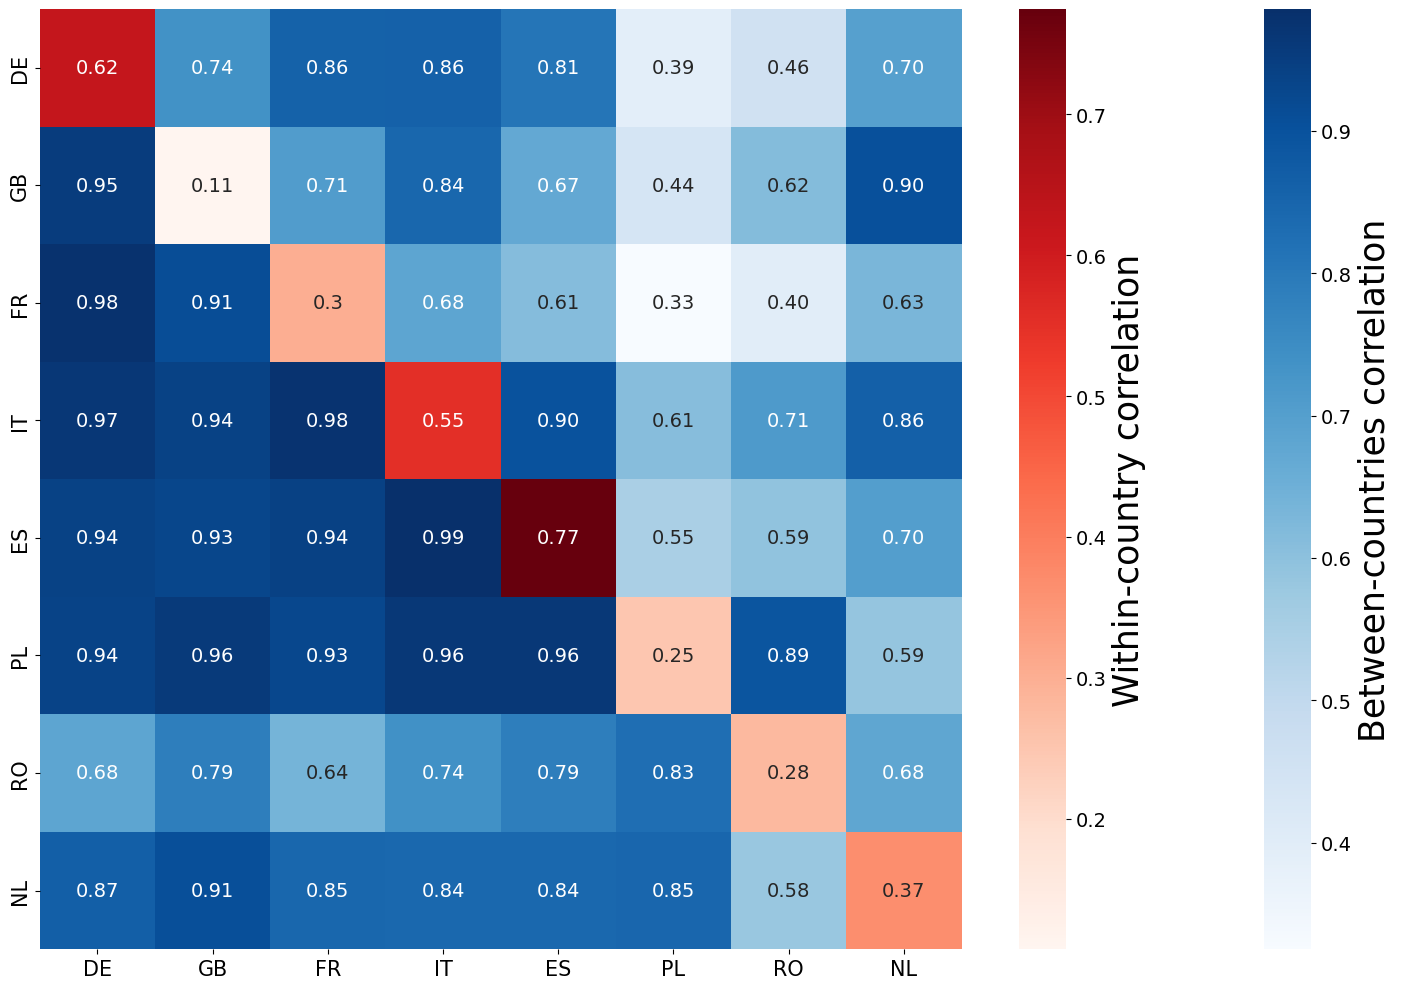

In [42]:
# correlation matrix:
# - under diagonal: correlation between vectors of each pair of countries with entries the money to each topic in RESEARCH
# - above diagonal: correlation between vectors of each pair of countries with entries the money to each topic in INDUSTRY
# - diagonal: correlation between vectors of money per topic in research and industry in single country

# embeddings type
emb_type = 'BGE' # paraphrase

country_list_matrix = list(indicator_matrix.index)
country_list_upper = [x.upper() for x in country_list_matrix]
indicator_matrix.index = [x.upper() for x in country_list_matrix]
indicator_matrix.columns = [x.upper() for x in country_list_matrix]

indicator_matrix = indicator_matrix.apply(pd.to_numeric, errors='coerce')

if reduced_countries:
    plt.figure(figsize=(15, 10))
else:
    plt.figure(figsize=(20, 20))

# Masks
mask_diag = np.eye(indicator_matrix.shape[0], dtype=bool)      # True on diagonal
mask_offdiag = ~mask_diag 

# first heatmap

ax = sns.heatmap(
    indicator_matrix,
    mask=mask_diag,
    cmap="Blues",      # colormap
    annot=True,          # show values
    #cbar=False,
    fmt=".2f", # number format
    cbar_kws={'label': 'Between-countries correlation'},
    annot_kws={"size":14}                 
)
#linewidths=0.10,      # grid lines
# linecolor="black"

# Adjust colorbar
cbar1 = ax.collections[0].colorbar
cbar1.ax.yaxis.label.set_size(25)
cbar1.ax.tick_params(labelsize=14)

# second heatmap

sns.heatmap(
    indicator_matrix,
    mask=mask_offdiag,
    cmap="Reds",
    annot=True,
    cbar_kws={'label': 'Within-country correlation'},
    #cbar=False,
    annot_kws={"size":14}            # avoid duplicate colorbar
)

# Adjust second colorbar
cbar2 = ax.collections[1].colorbar
cbar2.ax.yaxis.label.set_size(25)
cbar2.ax.tick_params(labelsize=14)

if reduced_countries:
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
else:
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)

plt.tight_layout()

# macro-topics manual (onyl for BGE)
#plt.savefig('research vs industry/matrix ' + emb_type + '/' + grouping_col + '_' + indicator_type + '_reduced_country_manual_labelled.pdf')
p#lt.savefig('research vs industry/matrix ' + emb_type + '/' + grouping_col + '_' + indicator_type + '_reduced_country_manual_labelled.png')

# macro_topics smi-manual
#plt.savefig('research vs industry/matrix ' + emb_type + '/' + grouping_col + '_' + indicator_type + '_country.pdf')

plt.show()

### Topic by country matrix

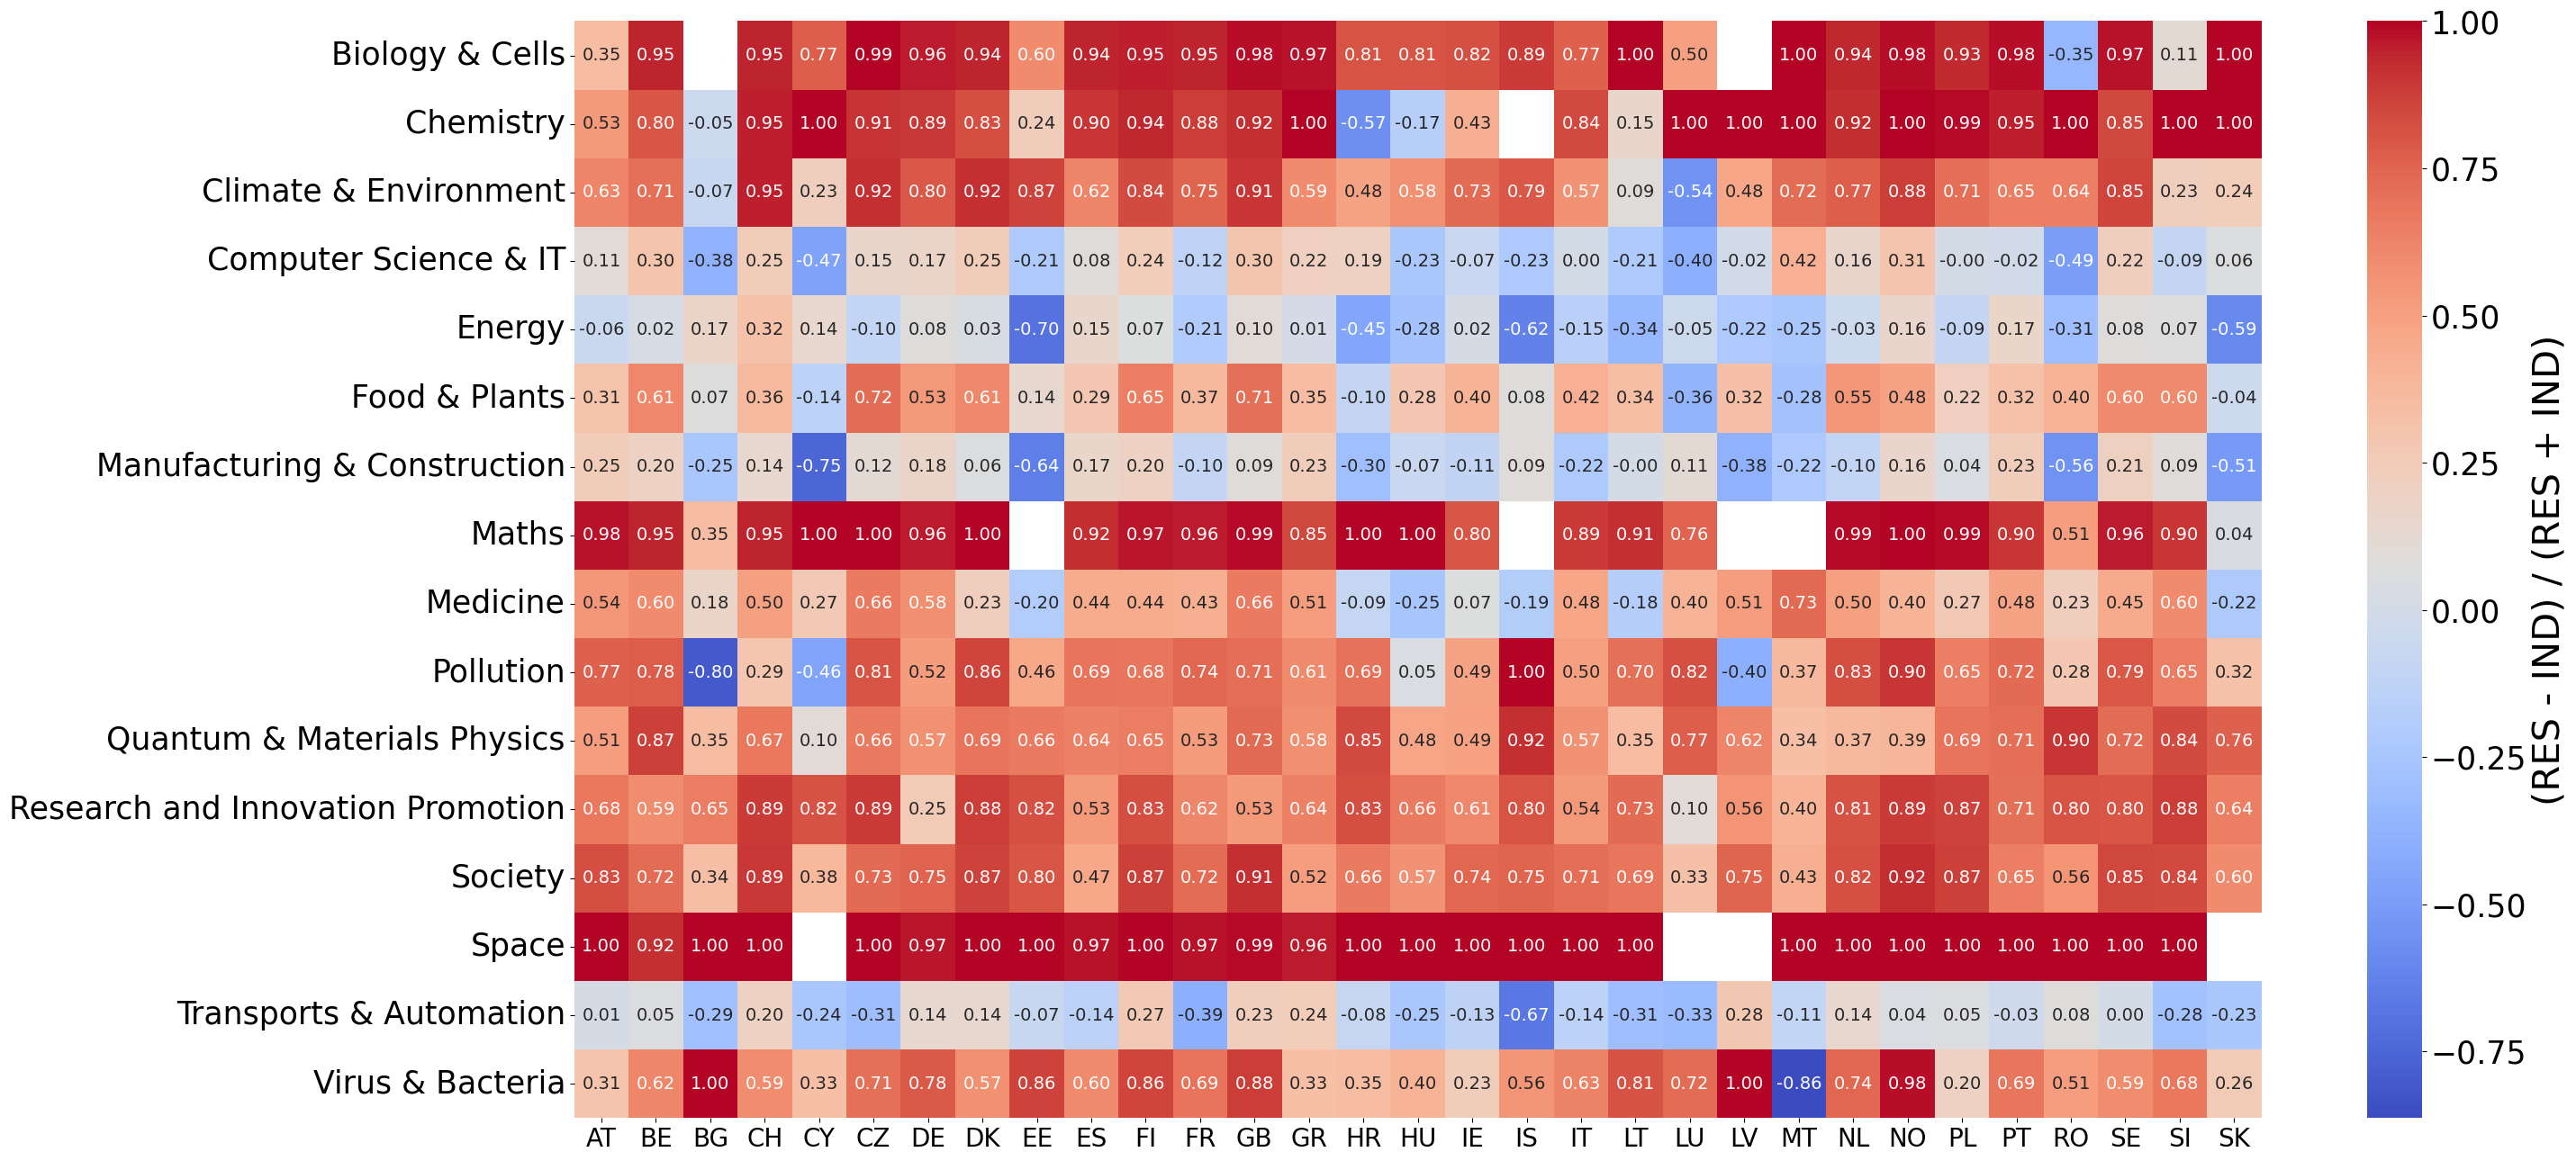

In [43]:
# embeddings type
emb_type = 'BGE' # paraphrase

df_topic_country = pd.DataFrame(index=country_list, columns=list(df_sorted_topic['topic_name']))
df_topic_country

for country in country_list:

    df_res_ind = country_res_ind_df[country_res_ind_df['country_code_original_nominatim'] == country]
    df_res_ind = pd.merge(df_sorted_topic, df_res_ind, on='topic_name', how='left')
    df_res_ind['r_i_sum'] = df_res_ind['ecNetContribution per capita_x'] + df_res_ind['ecNetContribution per capita_y']
    df_res_ind['r_i_diff'] = df_res_ind['ecNetContribution per capita_x'] - df_res_ind['ecNetContribution per capita_y']
    df_res_ind['res_ind_index'] = df_res_ind['r_i_diff'] / df_res_ind['r_i_sum']
    

    df_topic_country.loc[country] = list(df_res_ind['res_ind_index'])


# plot heatmap topics per country indicator

country_list_upper = [x.upper() for x in country_list]
df_topic_country.index = country_list_upper
#df_topic_country = df_topic_country.drop('LI', axis=0)
df_topic_country = df_topic_country.apply(pd.to_numeric, errors='coerce')

df_topic_country = df_topic_country.drop(index='LI')


plt.figure(figsize=(30, 13))

ax = sns.heatmap(
    df_topic_country.T,
    cmap="coolwarm",      # colormap
    annot=True,          # show values
    cbar=True,
    fmt=".2f",           # number format
    cbar_kws={'label': '(RES - IND) / (RES + IND)'},
    annot_kws={"size":14}   
)
#linewidths=0.10,      # grid lines
# linecolor="black"

cbar = ax.collections[0].colorbar
cbar.ax.yaxis.label.set_size(30)
cbar.ax.tick_params(labelsize=25)

plt.xticks(fontsize=20)
plt.yticks(fontsize=25)

plt.tight_layout()

# macro-topic manual (onyl BGE)
#plt.savefig('research vs industry/topics_country_res_ind_capita ' + emb_type + '_manual.png')
#plt.savefig('research vs industry/topics_country_res_ind_capita ' + emb_type + '_manual.pdf')
# macro-topic semi-manual
#plt.savefig('research vs industry/topics_country_res_ind_capita ' + emb_type + '.png')

plt.show()

# Plot money by country

## Group by country and sum ecMaxContribution: role

In [44]:
# df
df_8 = org_proj_8 # org_proj_8 or df_topics_new_embeddings_8
df_9 = org_proj_9 # org_proj_9 or df_topics_new_embeddings_9
df_tot = org_proj_tot # org_proj_tot or df_topics_new_embeddings

# efta countries


# topic name column
country_col = 'country_code_original_nominatim' #macro_topic_name or Name
# topic number col
#topic_num_col = 'macro_topic' #macro_topic or topic_num_forced
df_8['netEcContribution'] = df_8['netEcContribution'].astype(float) #str.replace(',', '.').
df_grouped_money_8 = df_8.groupby([country_col, 'role']).agg(sum_ecNetContribution=pd.NamedAgg(column='netEcContribution', aggfunc='sum'), count_proj=pd.NamedAgg(column='projectID', aggfunc='count'), mean_red_emb=pd.NamedAgg(column='mean_red_emb', aggfunc='first')).reset_index()

# remove rows where ecMaxContribution is HORIZON.1.2 or HORIZON.3.2
#org_proj_9 = org_proj_9[~org_proj_9['ecContribution'].isin(['HORIZON.1.2', 'HORIZON.3.2'])]
df_9 = df_9[~df_9['netEcContribution'].isin(['participant'])]
df_9['netEcContribution'] = df_9['netEcContribution'].astype(float)#.str.replace(',', '.')
df_grouped_money_9 = df_9.groupby([country_col, 'role']).agg(sum_ecNetContribution=pd.NamedAgg(column='netEcContribution', aggfunc='sum'), count_proj=pd.NamedAgg(column='projectID', aggfunc='count'), mean_red_emb=pd.NamedAgg(column='mean_red_emb', aggfunc='first')).reset_index()

#org_proj_tot_org = org_proj_tot_org[~org_proj_tot_org['ecContribution'].isin(['HORIZON.1.2', 'HORIZON.3.2'])]
df_tot = df_tot[~df_tot['netEcContribution'].isin(['participant'])]
df_tot['netEcContribution'] = df_tot['netEcContribution'].astype(float)#.str.replace(',', '.')
df_grouped_money_tot_country = df_tot.groupby([country_col, 'role']).agg(sum_ecNetContribution=pd.NamedAgg(column='netEcContribution', aggfunc='sum'), count_proj=pd.NamedAgg(column='projectID', aggfunc='count'), mean_red_emb=pd.NamedAgg(column='mean_red_emb', aggfunc='first')).reset_index()

# extract efat countries
df_grouped_money_tot_country_efta = df_grouped_money_tot_country[df_grouped_money_tot_country[country_col].isin(efta_countries)]

# add population info
pop_df = pd.read_csv(data_dir / 'population per year.csv')
pop_2023 = pop_df[['2023', 'Alpha-2 code']]
pop_2023 = pop_2023.rename(columns={'Alpha-2 code': country_col})
df_grouped_money_tot_country_efta[country_col] = df_grouped_money_tot_country_efta[country_col].str.upper()
df_grouped_money_tot_country_efta = pd.merge(df_grouped_money_tot_country_efta, pop_2023, on=country_col, how='left')
df_grouped_money_tot_country_efta['ecNetContribution per capita'] = df_grouped_money_tot_country_efta['sum_ecNetContribution'] / df_grouped_money_tot_country_efta['2023']

/tmp/ipykernel_521596/3204442682.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_9['netEcContribution'] = df_9['netEcContribution'].astype(float)#.str.replace(',', '.')
/tmp/ipykernel_521596/3204442682.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tot['netEcContribution'] = df_tot['netEcContribution'].astype(float)#.str.replace(',', '.')
/tmp/ipykernel_521596/3204442682.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_ind

### Stacked barplot - by role

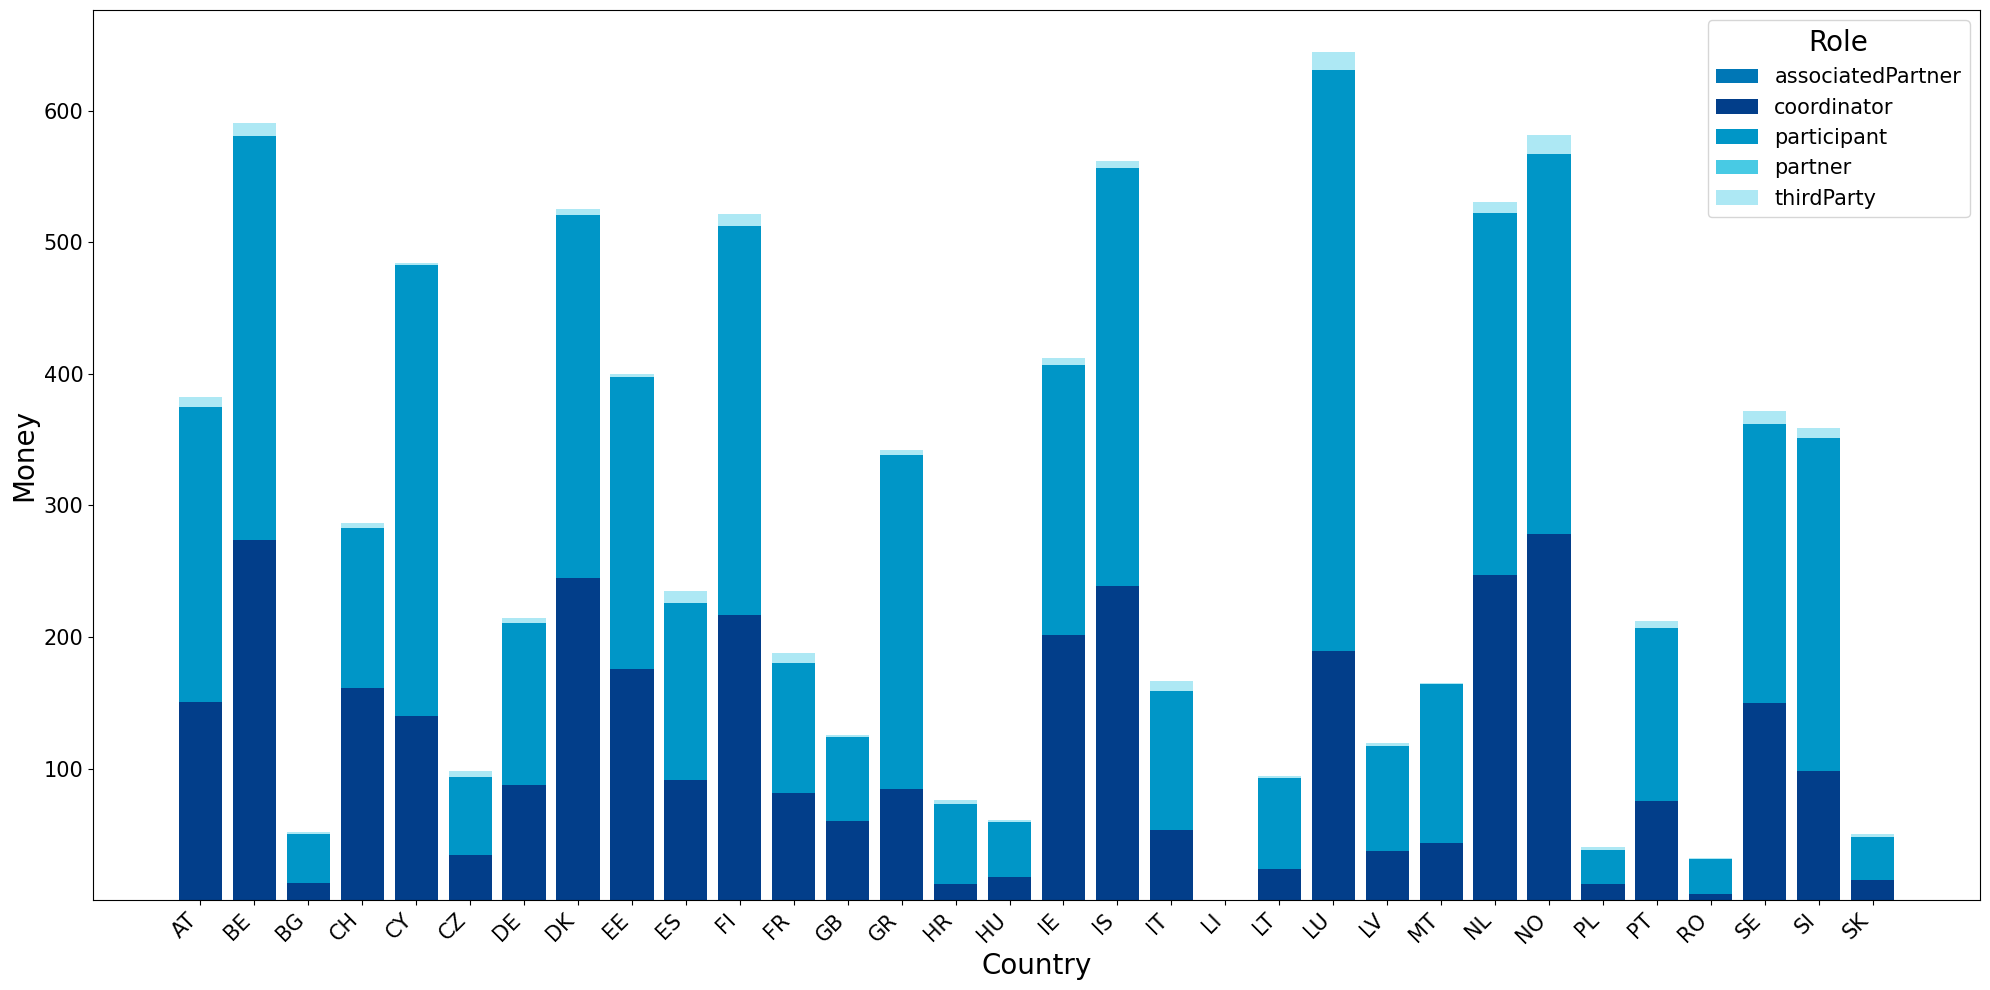

In [47]:
# plot by country

values = 'ecNetContribution per capita' # or sum_ecNetContribution

color_map = {
    'associatedPartner': '#0077b6',
    'coordinator': '#023e8a',
    'participant': '#0096c7',
    'partner': '#48cae4',
    'thirdParty': '#ade8f4'
}



'''[[215./255,48./255,39./255],
             [252./255,141./255,89./255],
             [254./255,224./255,144./255],
             [224./255,243./255,248./255],
             [145./255,191./255,219./255]
             ]#,[69./255,117./255,180./255]'''

# settings
ticks_size = 15
labels_size = 20
legend_size = 15
legend_title = 20

# 1 — Pivot the data (rows=countries, columns=organization types)

df_pivot = df_grouped_money_tot_country_efta.pivot_table(
    index='country_code_original_nominatim',
    columns='role',
    values=values,
    aggfunc='sum',
    fill_value=0,
    
)

# 2 — Create plot

fig, ax = plt.subplots(figsize=(20, 10))

# x locations
countries = df_pivot.index
x = range(len(countries))

# Start at zero for stacking
bottom = [0] * len(countries)

# 3 — Plot each organization type as one layer of the stack
for role_type in df_pivot.columns:
    ax.bar(
        x,
        df_pivot[role_type],
        bottom=bottom,
        label=role_type,
        color=color_map.get(role_type, 'gray')
    )
    # Update the bottom for next stack segment
    bottom = bottom + df_pivot[role_type].values

# 4 — Formatting
ax.set_xticks(x)
ax.tick_params(axis='x', labelsize=ticks_size)
ax.set_xticklabels(countries, rotation=45, ha="right", fontsize=ticks_size)
ax.tick_params(axis='y', labelsize=ticks_size)
ax.set_ylabel("Money", fontsize=labels_size)
ax.set_xlabel("Country", fontsize=labels_size)
#ax.set_title("Money by Country and Role")
ax.legend(title="Role", loc="upper right", fontsize=legend_size, title_fontsize=legend_title)
#bbox_to_anchor=(1.05, 1), 
plt.tight_layout()
plt.show()

## Group by country and sum ecMaxContribution: activityType

In [48]:
# df
df_8 = org_proj_tot_8 # org_proj_8 or df_topics_new_embeddings_8
df_9 = org_proj_tot_9 # org_proj_9 or df_topics_new_embeddings_9
df_tot = org_proj_tot # org_proj_tot or df_topics_new_embeddings

# efta countries


# topic name column
country_col = 'country_code_original_nominatim' #macro_topic_name or Name
activity_col = 'activityType_new'
# topic number col
#topic_num_col = 'macro_topic' #macro_topic or topic_num_forced
df_8['netEcContribution'] = df_8['netEcContribution'].astype(float) #str.replace(',', '.').
df_grouped_money_8 = df_8.groupby([country_col, activity_col]).agg(sum_ecNetContribution=pd.NamedAgg(column='netEcContribution', aggfunc='sum'), count_proj=pd.NamedAgg(column='projectID', aggfunc='count'), mean_red_emb=pd.NamedAgg(column='mean_red_emb', aggfunc='first')).reset_index()

# remove rows where ecMaxContribution is HORIZON.1.2 or HORIZON.3.2
#org_proj_9 = org_proj_9[~org_proj_9['ecContribution'].isin(['HORIZON.1.2', 'HORIZON.3.2'])]
df_9 = df_9[~df_9['netEcContribution'].isin(['participant'])]
df_9['netEcContribution'] = df_9['netEcContribution'].astype(float)#.str.replace(',', '.')
df_grouped_money_9 = df_9.groupby([country_col, activity_col]).agg(sum_ecNetContribution=pd.NamedAgg(column='netEcContribution', aggfunc='sum'), count_proj=pd.NamedAgg(column='projectID', aggfunc='count'), mean_red_emb=pd.NamedAgg(column='mean_red_emb', aggfunc='first')).reset_index()

#org_proj_tot_org = org_proj_tot_org[~org_proj_tot_org['ecContribution'].isin(['HORIZON.1.2', 'HORIZON.3.2'])]
df_tot = df_tot[~df_tot['netEcContribution'].isin(['participant'])]
df_tot['netEcContribution'] = df_tot['netEcContribution'].astype(float)#.str.replace(',', '.')
df_grouped_money_tot_country = df_tot.groupby([country_col, activity_col]).agg(sum_ecNetContribution=pd.NamedAgg(column='netEcContribution', aggfunc='sum'), count_proj=pd.NamedAgg(column='projectID', aggfunc='count'), mean_red_emb=pd.NamedAgg(column='mean_red_emb', aggfunc='first')).reset_index()

# extract efat countries
df_grouped_money_tot_country_efta = df_grouped_money_tot_country[df_grouped_money_tot_country[country_col].isin(efta_countries)]

# add population info
pop_df = pd.read_csv(data_dir / 'population per year.csv')
pop_2023 = pop_df[['2023', 'Alpha-2 code']]
pop_2023 = pop_2023.rename(columns={'Alpha-2 code': country_col})
df_grouped_money_tot_country_efta[country_col] = df_grouped_money_tot_country_efta[country_col].str.upper()
df_grouped_money_tot_country_efta = pd.merge(df_grouped_money_tot_country_efta, pop_2023, on=country_col, how='left')
df_grouped_money_tot_country_efta['ecNetContribution per capita'] = df_grouped_money_tot_country_efta['sum_ecNetContribution'] / df_grouped_money_tot_country_efta['2023']

/tmp/ipykernel_521596/976465347.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_8['netEcContribution'] = df_8['netEcContribution'].astype(float) #str.replace(',', '.').
/tmp/ipykernel_521596/976465347.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_9['netEcContribution'] = df_9['netEcContribution'].astype(float)#.str.replace(',', '.')


/tmp/ipykernel_521596/976465347.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tot['netEcContribution'] = df_tot['netEcContribution'].astype(float)#.str.replace(',', '.')
/tmp/ipykernel_521596/976465347.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_grouped_money_tot_country_efta[country_col] = df_grouped_money_tot_country_efta[country_col].str.upper()


### Stacked barplot - by org rtype

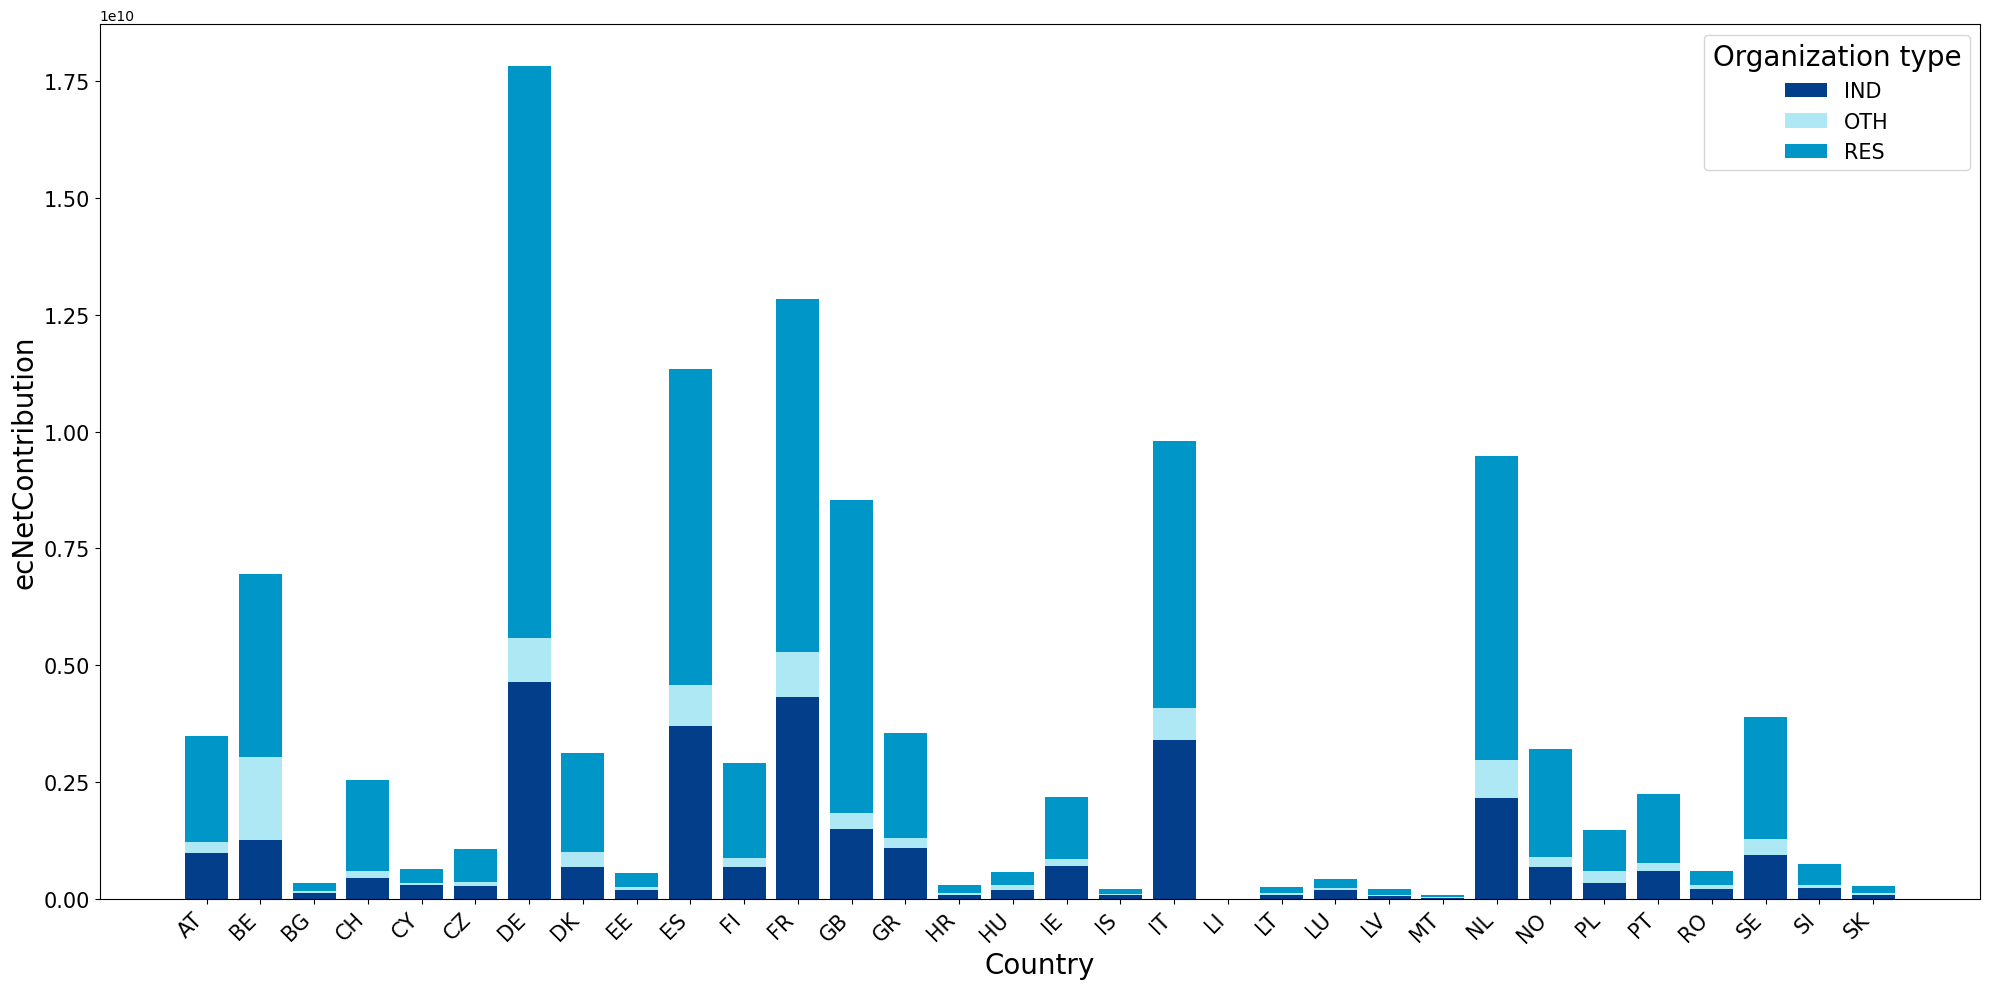

In [49]:
# plot by country

values = 'sum_ecNetContribution' # or ecNetContribution per capita

color_map = {
    'RES': '#0096c7',
    'IND': '#023e8a',
    'OTH': '#ade8f4'
}



'''[[215./255,48./255,39./255],
             [252./255,141./255,89./255],
             [254./255,224./255,144./255],
             [224./255,243./255,248./255],
             [145./255,191./255,219./255]
             ]#,[69./255,117./255,180./255]'''

# settings
ticks_size = 15
labels_size = 20
legend_size = 15
legend_title = 20

# 1 — Pivot the data (rows=countries, columns=organization types)

df_pivot = df_grouped_money_tot_country_efta.pivot_table(
    index='country_code_original_nominatim',
    columns='activityType_new',
    values=values,
    aggfunc='sum',
    fill_value=0,
    
)

# 2 — Create plot

fig, ax = plt.subplots(figsize=(20, 10))

# x locations
countries = df_pivot.index
x = range(len(countries))

# Start at zero for stacking
bottom = [0] * len(countries)

# 3 — Plot each organization type as one layer of the stack
for role_type in df_pivot.columns:
    ax.bar(
        x,
        df_pivot[role_type],
        bottom=bottom,
        label=role_type,
        color=color_map.get(role_type, 'gray')
    )
    # Update the bottom for next stack segment
    bottom = bottom + df_pivot[role_type].values

# 4 — Formatting
ax.set_xticks(x)
ax.tick_params(axis='x', labelsize=ticks_size)
ax.set_xticklabels(countries, rotation=45, ha="right", fontsize=ticks_size)
ax.tick_params(axis='y', labelsize=ticks_size)
ax.set_ylabel("ecNetContribution", fontsize=labels_size)
ax.set_xlabel("Country", fontsize=labels_size)
#ax.set_title("Money by Country and Role")
ax.legend(title="Organization type", loc="upper right", fontsize=legend_size, title_fontsize=legend_title)
#bbox_to_anchor=(1.05, 1), 
plt.tight_layout()
plt.show()

#fig.savefig('FBK analysis/barplot money/' + values + '_country_role.png')

### Choroplet money per region

In [50]:
""" LOAD POP """
def loadPopulationData():
    #This loads population data from Eurostat
    print('LOAD POPULATION')

    """ COUNTRIES """
    countries_data = pd.read_csv(data_dir / 'worlddata.info/countries.csv', delimiter = ';')
    pop_cid = {row['Country code']: row['Population'] for i,row in countries_data.iterrows()}

    """ NUTS3 """ #For A
    df_pop_ori = pd.read_csv(data_dir / 'Eurostat/demo_r_pjangrp3.tsv', delimiter = '\t')
    rev = df_pop_ori.iloc[:,0].apply(lambda x: pd.Series(x.split(','))) #Separate indeces
    pp  = df_pop_ori['2015 '].apply(lambda x: pd.Series(x.split(' ')))  #Separate indicator estimation data
    rev.rename(columns={0:'sex',1:'unit',2:'age',3:'geo'},inplace = True) #Rename & merge
    pp.rename(columns={0:'pop',1:'err'},inplace = True)
    df_pop = pd.concat([rev,pp], axis = 1)
    df_pop = df_pop[(rev.sex == 'T') & (rev.age == 'TOTAL')]
    #df_pop = df_pop[df_pop['pop'] != ':'] #Clean missing error and set to numeric                                           
    df_pop['pop'] = pd.to_numeric(df_pop['pop'], errors = 'coerce') 
    pop_nuts = {row['geo']: row['pop'] for i,row in df_pop.iterrows()}

    return pop_cid,pop_nuts

pop_cid,pop_nuts = loadPopulationData()

LOAD POPULATION


In [51]:
""" CREATE A DATAFRAME"""
df_POP_nuts3 = pd.Series({k:v for k,v in pop_nuts.items() if len(k) == 5})
df_POP_nuts3 = pd.DataFrame({'NUTS_ID':df_POP_nuts3.index,'POP':df_POP_nuts3.values})
df_POP_nuts3

df_POP_nuts2 = pd.Series({k:v for k,v in pop_nuts.items() if len(k) == 4})
df_POP_nuts2 = pd.DataFrame({'NUTS_ID':df_POP_nuts2.index,'POP':df_POP_nuts2.values})
df_POP_nuts2.tail()

,NUTS_ID,POP
321,UKM2,2059154.0
322,UKM3,2339246.0
323,UKM5,490534.0
324,UKM6,467566.0
325,UKN0,1847100.0


In [56]:
# nuts df
gdf_NUTS = gpd.read_file(data_dir / 'NUTS_RG_01M_2013_4326/NUTS_RG_01M_2013_4326.shp')

# set nuts level to use
nuts_level = 2 # 2

# efta countries
efta_df = pd.read_csv(data_dir / 'efta countries.csv')
efta_countries = efta_df['country']
gdf_NUTS['CNTR_CODE'] = gdf_NUTS['CNTR_CODE'].replace({'EL': 'GR', 'UK': 'GB'})

# filter by nuts level and efta countries
gdf_NUTS_level = gdf_NUTS[(gdf_NUTS['LEVL_CODE'] == nuts_level) & (gdf_NUTS['CNTR_CODE'].isin(efta_countries))]

# merge population df nuts 2
if nuts_level == 2:
    gdf_NUTS_level = pd.merge(gdf_NUTS_level, df_POP_nuts2, on='NUTS_ID', how='left')

# filter by nuts level and specific country
#gdf_NUTS_level = gdf_NUTS[(gdf_NUTS['LEVL_CODE'] == nuts_level) & (gdf_NUTS['CNTR_CODE'] == 'IT')]

# filter by specific region
#gdf_NUTS_level = gdf_NUTS_level[gdf_NUTS_level['NUTS_NAME'] == 'Provincia Autonoma di Trento']

In [ ]:
# org dir
org_dir = data_dir / 'organizations/'
# proj dir
proj_dir = data_dir / 'projects/'

# read efta countries
efta_df = pd.read_csv(data_dir / 'efta countries.csv')
efta_countries = list(efta_df['country'].map(lambda x: x.lower()))

nuts_list = []
    
org_df = df_tot

# covert to GeoDataFrame
gdf_points = gpd.GeoDataFrame(
    data=org_df,
    geometry=[Point(xy) for xy in zip(org_df['lon_cordis_nominatim'], org_df['lat_cordis_nominatim'])],
    crs="EPSG:4326"   # WGS84
)

# spatial join
joined = gpd.sjoin(gdf_points, gdf_NUTS_level, how='left', predicate='within')

if nuts_level == 0:
    # add population info
    pop_df = pd.read_csv('useful stuff/population per year.csv')
    pop_2023 = pop_df[['2023', 'Alpha-2 code']]
    pop_2023 = pop_2023.rename(columns={'Alpha-2 code': country_col})
    joined[country_col] = joined[country_col].str.upper()
    joined = pd.merge(joined, pop_2023, on=country_col, how='left')

nuts_list += [joined]

In [ ]:
# group by nuts and count number of collaborations in each

activity = 'TOT'

if activity == 'RES':
    nuts = joined[joined['activityType_new'] == 'RES']
elif activity == 'IND':
    nuts = joined[joined['activityType_new'] == 'IND']
else:
    nuts = joined

if nuts_level == 0:
    nuts_grouped = nuts.groupby('NUTS_ID').agg(NUTS_ID=pd.NamedAgg(column='NUTS_ID', aggfunc='first'), count_coll=pd.NamedAgg(column='NUTS_ID', aggfunc='count'), sum_ecNetContribution=pd.NamedAgg(column='netEcContribution', aggfunc='sum'), pop_2023=pd.NamedAgg(column='2023', aggfunc='first')).reset_index(drop=True)
    nuts_grouped['sum_ecNetContribution'] = nuts_grouped['sum_ecNetContribution'].replace(0, np.nan)
    nuts_grouped['ecNetContribution per capita'] = nuts_grouped['sum_ecNetContribution'] / nuts_grouped['pop_2023']
else:
    nuts_grouped = nuts.groupby('NUTS_ID').agg(NUTS_ID=pd.NamedAgg(column='NUTS_ID', aggfunc='first'), count_coll=pd.NamedAgg(column='NUTS_ID', aggfunc='count'), sum_ecNetContribution=pd.NamedAgg(column='netEcContribution', aggfunc='sum'), pop_nuts2=pd.NamedAgg(column='POP', aggfunc='first')).reset_index(drop=True)
    nuts_grouped['sum_ecNetContribution'] = nuts_grouped['sum_ecNetContribution'].replace(0, np.nan)
    nuts_grouped['ecNetContribution per capita'] = nuts_grouped['sum_ecNetContribution'] / nuts_grouped['pop_nuts2']
    
gdf = gdf_NUTS_level.merge(nuts_grouped, on='NUTS_ID', how='left')

In [ ]:
'''gdf.to_file('maps_files/TOT_gdf_nuts2.shp')
gdf.to_file('maps_files/TOT_gdf_nuts2.geojson', driver='GeoJSON')

gdf_nuts0 = gpd.read_file("maps_files/TOT_gdf_nuts0.geojson")
gdf_nuts2 = gpd.read_file("maps_files/TOT_gdf_nuts2.geojson")

gdf_nuts0.to_csv('maps_files/TOT_gdf_nuts0.csv', index=False)
gdf_nuts2.to_csv('maps_files/TOT_gdf_nuts2.csv', index=False)

df_nuts0 = pd.read_csv("maps_files/TOT_gdf_nuts0.csv")
df_nuts2 = pd.read_csv("maps_files/TOT_gdf_nuts2.csv")'''

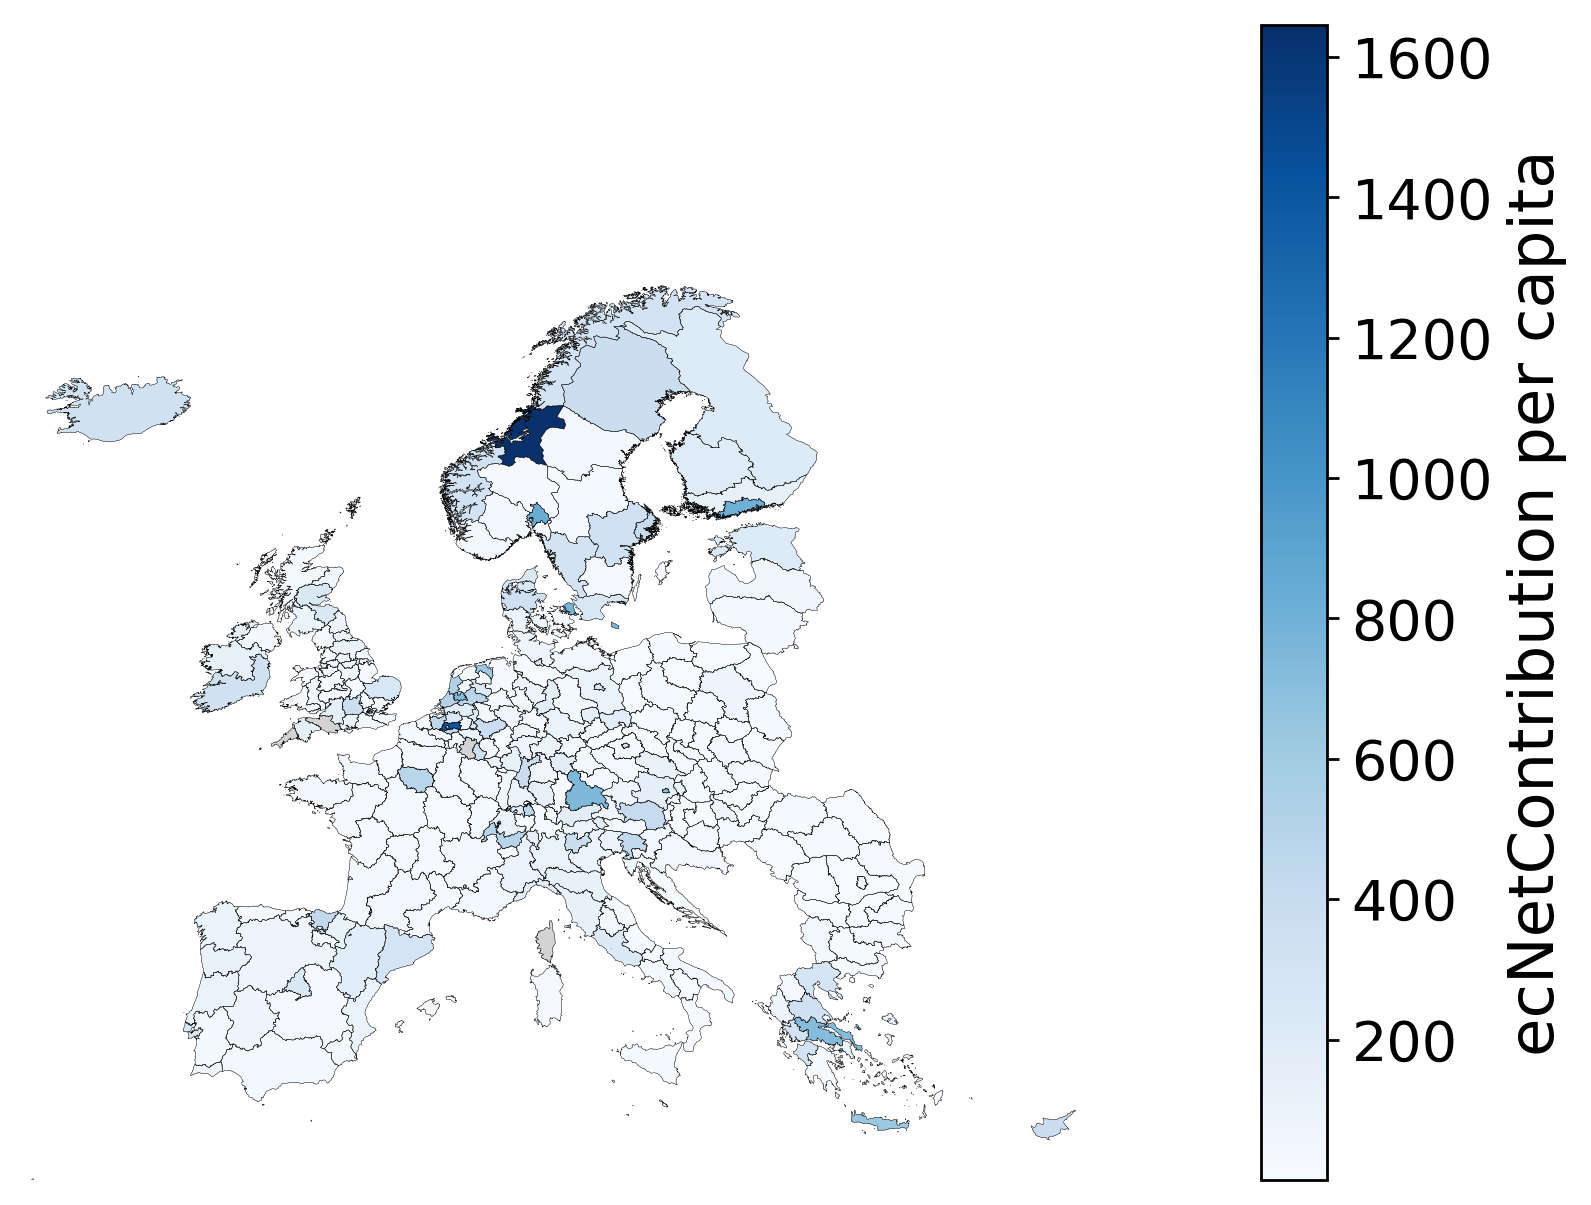

In [ ]:
# output dir
output_dir = parent_dir / 'Analysis' / 'geography' / 'choroplets_money_region'

money_col = 'ecNetContribution per capita' #sum_ecNetContribution

if money_col == 'sum_ecNetContribution':
    plot_legend = 'ecNetContribution'
else:
    plot_legend = 'ecNetContribution per capita'
# iterate over nuts geodataframes

#for i in range(len(nuts_grouped_list)):

# Create figure with custom GridSpec
fig = plt.figure(figsize=(7, 6), dpi=250)
gs = gridspec.GridSpec(1, 2, width_ratios=[0.95, 0.05], wspace=0.04)

# Axes for main map and colorbar
ax = fig.add_subplot(gs[0])
cax = fig.add_subplot(gs[1])

nuts3_grouped = gdf #nuts_grouped_list[i]
#fig, ax = plt.subplots(1, 1, figsize=(12, 8))

nuts3_grouped = nuts3_grouped.to_crs('+proj=moll')
nuts3_grouped = nuts3_grouped.set_geometry('geometry')
nuts3_grouped.plot(
    column=money_col, 
    cmap="Blues",#OrRd
    missing_kwds={'color': 'lightgrey'},
    linewidth=0.05, 
    edgecolor="black", 
    legend=True, 
    legend_kwds={'label': ''},
    cax=cax,
    ax=ax,
    #norm=colors.LogNorm(vmin=gdf[money_col].min(), vmax=gdf[money_col].max())
    )

nuts3_grouped.boundary.plot(color='black', ax=ax, linewidth=0.1)

# Axis settings
# Europe
ax.set(xlim=(-1500000, 3500000), ylim=(4000000, 9000000))
# Italy
#ax.set(xlim=(300000, 1700000) ,ylim=(4300000, 5650000))
ax.axis('off')
# e ax.set_title("Projects per NUTS-3 region", fontsize=16)


# Format colorbar
cax.set_ylabel(plot_legend, rotation=90, fontsize=18)
cax.tick_params(labelsize=16)
cax.yaxis.set_ticks_position('right')
cax.yaxis.set_label_position('right')
cax.set_xticks([])  # Optional: remove x ticks if unwanted

#plt.savefig(output_dir + activity + '_' + plot_legend + '_' + str(nuts_level) + '.png', dpi=250, bbox_inches='tight')

plt.show()
